# Section 0 — Imports & setup

- Mount Drive, import libraries
- Load `llm_results`, `nlp_results` pickles
- Define `EMOTIONS`, `TASTES`, constants
- Download Kaggle dataset, build `image_lookup`

In [1]:
import os, glob, re, pickle, io
from collections import Counter

import numpy as np
import pandas as pd
import math

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib.patches import RegularPolygon, FancyArrowPatch, Circle, Rectangle, Polygon as MplPolygon
import matplotlib.patheffects as pe
from matplotlib.path import Path
from matplotlib.lines import Line2D
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import seaborn as sns
from PIL import Image, ImageDraw, ImageFont

from scipy.stats import spearmanr, gaussian_kde
from sklearn.manifold import TSNE
from scipy.spatial.distance import jensenshannon

from google.colab import drive
drive.mount('/content/drive')

print('All imports OK')

Mounted at /content/drive
All imports OK


In [2]:
# Label lists
EMOTIONS = [
    'Happy', 'Pleasure', 'Astonished', 'Relaxed', 'Satisfied',
    'Tired', 'Fear', 'Angry', 'Annoyed', 'Sad', 'Disgust', 'Droopy'
]
TASTES = ['Sweet', 'Sour', 'Salty', 'Bitter', 'Umami']

EMOTIONS_LOWER = [e.lower() for e in EMOTIONS]
TASTES_LOWER   = [t.lower() for t in TASTES]
N_BOOKS        = 60

# Colour maps
EMOTION_COLORS = {
    'happy':'#97C459','pleasure':'#5DCAA5','astonished':'#FAC775',
    'relaxed':'#85B7EB','satisfied':'#AFA9EC','tired':'#B4B2A9',
    'fear':'#F09595','angry':'#E24B4A','annoyed':'#D85A30',
    'sad':'#378ADD','disgust':'#639922','droopy':'#888780',
}
EMOTION_PALETTE = {k.capitalize(): v for k, v in EMOTION_COLORS.items()}
TASTE_PALETTE = {
    'Sweet':'#F4C0D1','Sour':'#C0DD97','Salty':'#B5D4F4',
    'Bitter':'#D3D1C7','Umami':'#FAC775',
}

# File paths
EMOTION_FILE = '/content/drive/MyDrive/user-study/20260327_Conjointly_experiment_646348.xlsx'
TASTE_FILE   = '/content/drive/MyDrive/user-study/20260327_Conjointly_experiment_646190.xlsx'
MAPPING_FILE = '/content/drive/MyDrive/user-study/q_to_book_mapping.xlsx'
IMAGE_FOLDER = '/content/drive/MyDrive/latest_llm'

print(f'Emotions ({len(EMOTIONS)}): {EMOTIONS}')
print(f'Tastes   ({len(TASTES)}):   {TASTES}')


Emotions (12): ['Happy', 'Pleasure', 'Astonished', 'Relaxed', 'Satisfied', 'Tired', 'Fear', 'Angry', 'Annoyed', 'Sad', 'Disgust', 'Droopy']
Tastes   (5):   ['Sweet', 'Sour', 'Salty', 'Bitter', 'Umami']


In [3]:
# Single source: emotion > (quadrant, pattern)
EMOTION_QUADRANT = {
    'happy':      ('Q1', 'solid'),
    'pleasure':   ('Q1', 'lines'),
    'astonished': ('Q1', 'dots'),
    'angry':      ('Q2', 'solid'),
    'fear':       ('Q2', 'lines'),
    'annoyed':    ('Q2', 'dots'),
    'sad':        ('Q3', 'solid'),
    'disgust':    ('Q3', 'lines'),
    'droopy':     ('Q3', 'dots'),
    'relaxed':    ('Q4', 'solid'),
    'satisfied':  ('Q4', 'lines'),
    'tired':      ('Q4', 'dots'),
}

QUADRANT_SHAPE = {'Q1': 'flower', 'Q2': 'triangle', 'Q3': 'circle', 'Q4': 'square'}

EMOTION_SHAPE   = {e.capitalize(): QUADRANT_SHAPE[q]
                   for e, (q, _) in EMOTION_QUADRANT.items()}
EMOTION_PATTERN = {e.capitalize(): p
                   for e, (_, p) in EMOTION_QUADRANT.items()}

def emotion_to_quadrant(emotion):
    return EMOTION_QUADRANT.get(emotion.lower(), ('Q3', 'solid'))[0]

def emotion_to_fill(emotion):
    return EMOTION_QUADRANT.get(emotion.lower(), ('Q3', 'solid'))[1]

# Taste mappings
TASTE_SHAPE = {
    'Sweet': 'circle', 'Sour': 'star', 'Salty': 'triangle',
    'Bitter': 'square', 'Umami': 'flower',
}

In [4]:
# Load CLIP / NLP results
with open('/content/drive/MyDrive/dataset/llm_rankings.pkl', 'rb') as f:
    llm_results = pickle.load(f)
with open('/content/drive/MyDrive/dataset/nlp_rankings.pkl', 'rb') as f:
    nlp_results = pickle.load(f)

print('LLM emotions:', list(llm_results['emotion'].keys()))
print('LLM tastes:  ', list(llm_results['taste'].keys()))

# Kaggle image lookup (ISBN filename → Kaggle cache path)
import kagglehub
dataset_path = kagglehub.dataset_download('mexwell/book-cover-dataset')
all_kaggle = (
    glob.glob(os.path.join(dataset_path, '**/*.jpg'),  recursive=True) +
    glob.glob(os.path.join(dataset_path, '**/*.jpeg'), recursive=True) +
    glob.glob(os.path.join(dataset_path, '**/*.png'),  recursive=True)
)
image_lookup = {os.path.basename(p): p for p in all_kaggle}
print(f'Kaggle images indexed: {len(image_lookup):,}')

# Local image lookup (renamed files in latest_llm → full path)
all_local = (
    glob.glob(os.path.join(IMAGE_FOLDER, '**/*.jpg'),  recursive=True) +
    glob.glob(os.path.join(IMAGE_FOLDER, '**/*.jpeg'), recursive=True) +
    glob.glob(os.path.join(IMAGE_FOLDER, '**/*.png'),  recursive=True)
)
local_lookup = {os.path.basename(p): p for p in all_local}
print(f'Local images indexed:  {len(local_lookup):,}')

LLM emotions: ['happy', 'pleasure', 'astonished', 'relaxed', 'satisfied', 'tired', 'fear', 'angry', 'annoyed', 'sad', 'disgust', 'droopy']
LLM tastes:   ['sweet', 'sour', 'salty', 'bitter', 'umami']


100%|██████████| 675M/675M [00:05<00:00, 122MB/s]

Extracting files...


Kaggle images indexed: 57,000
Local images indexed:  60


In [5]:
# Helper functions

def resolve_path(fname):
    """Try .jpg / .jpeg / .png extensions in local_lookup."""
    fname = str(fname)
    for ext in ['.jpg', '.jpeg', '.png']:
        p = local_lookup.get(fname + ext)
        if p: return p
    return None

def sort_key(fname):
    """Sort filenames like 6_r3 → (6, 3) for group ordering."""
    m = re.match(r'(\d+)_r(\d+)', str(fname))
    return (int(m.group(1)), int(m.group(2))) if m else (99, 99)

def load_human_study(filepath, q_pattern, label_list, valid_q_nums):
    """
    valid_q_nums: set of Q numbers from mapping file marked as real books.
    Only processes those Q numbers — skips trials AND quality tests.
    """
    df = pd.read_excel(filepath, sheet_name='Respondents', header=1)
    df.columns = df.iloc[0]
    df = df.iloc[1:].reset_index(drop=True)
    completed = df[df['Status of response'] == 'Completed survey'].copy()
    print(f'  Completed respondents: {len(completed)}')

    q_cols = [c for c in df.columns if isinstance(c, str)
              and re.search(q_pattern, c) and 'Option' not in c]
    print(f'  Total question columns found: {len(q_cols)}')

    results = []
    skipped = 0
    for col in q_cols:
        q_match = re.match(r'Q(\d+)', col)
        if not q_match: continue
        q_num = int(q_match.group(1))

        # Only process Q numbers that are real books in the mapping
        if q_num not in valid_q_nums:
            skipped += 1
            continue

        counts  = Counter(completed[col].dropna().str.strip().str.lower())
        n_votes = sum(counts.values())
        top1    = counts.most_common(1)[0][0] if counts else None
        prob_vector = np.zeros(len(label_list))
        if n_votes > 0:
            for i, label in enumerate(label_list):
                prob_vector[i] = counts.get(label.lower(), 0) / n_votes
        results.append({
            'q_num':         q_num,
            'top1':          top1,
            'probabilities': prob_vector,
            'vote_counts':   dict(counts),
            'n_votes':       n_votes,
        })

    print(f'  Real book columns processed: {len(results)} (skipped {skipped} trials/quality tests)')
    return results

def plot_matrix_with_thumbs(matrix, row_labels, image_paths, border_emotions,
                             title, cmap, fmt, vmin=None, vmax=None,
                             matrix_h=5.0, savefile=None):
    """Render a heatmap with book cover thumbnails on top."""
    n_books = matrix.shape[0]
    THUMB_H = 0.8; TOTAL_W = 30
    fig = plt.figure(figsize=(TOTAL_W, 0.4 + THUMB_H + matrix_h))
    gs  = gridspec.GridSpec(3, n_books,
            height_ratios=[0.4, THUMB_H, matrix_h], hspace=0.02, wspace=0.05)
    ax_title = fig.add_subplot(gs[0, :])
    ax_title.axis('off')
    ax_title.text(0.5, 0.5, title, ha='center', va='center',
                  fontsize=13, transform=ax_title.transAxes)
    for col_i, (path, em) in enumerate(zip(image_paths, border_emotions)):
        ax_img = fig.add_subplot(gs[1, col_i])
        ax_img.axis('off')
        color = EMOTION_COLORS.get(str(em).lower(), '#ccc')
        for spine in ax_img.spines.values():
            spine.set_edgecolor(color); spine.set_linewidth(2); spine.set_visible(True)
        if path and os.path.exists(path):
            try:
                img = Image.open(path).convert('RGB')
                img.thumbnail((80, 120))
                ax_img.imshow(np.array(img), aspect='auto')
            except: ax_img.set_facecolor('#eee')
        else: ax_img.set_facecolor('#eee')
    df = pd.DataFrame(matrix.T, index=row_labels,
                      columns=[f'B{i+1:02d}' for i in range(n_books)])
    ax_heat = fig.add_subplot(gs[2, :])
    kwargs = dict(ax=ax_heat, annot=True, fmt=fmt, annot_kws={'size': 6},
                  cmap=cmap, linewidths=0.8, linecolor='white', cbar=False)
    if vmin is not None: kwargs['vmin'] = vmin
    if vmax is not None: kwargs['vmax'] = vmax
    sns.heatmap(df, **kwargs)
    ax_heat.set_xlabel('')
    ax_heat.set_ylabel('', fontsize=11)
    ax_heat.tick_params(axis='x', bottom=False, labelbottom=False)
    ax_heat.tick_params(axis='y', rotation=0, labelsize=9)
    if savefile: plt.savefig(savefile, dpi=150, bbox_inches='tight')
    plt.show()

def plot_va_covers(va, labels, palette, title, image_paths, savefile,
                   thumb_size=(60, 94), padding=0.05, border_size=10, force_lim=None):

    if force_lim is not None:
        v_min, v_max = -force_lim, force_lim
        a_min, a_max = -force_lim, force_lim
    else:
        v_range = va[:,0].max() - va[:,0].min()
        a_range = va[:,1].max() - va[:,1].min()
        max_range = max(v_range, a_range)
        v_center = (va[:,0].max() + va[:,0].min()) / 2
        a_center = (va[:,1].max() + va[:,1].min()) / 2
        v_min = v_center - max_range/2 - padding
        v_max = v_center + max_range/2 + padding
        a_min = a_center - max_range/2 - padding
        a_max = a_center + max_range/2 + padding

    fig, ax = plt.subplots(figsize=(11, 11))
    ax.set_title(title, fontsize=12, pad=12)
    ax.set_xlabel('Valence  (negative ← → positive)', fontsize=10)
    ax.set_ylabel('Arousal  (calm ← → intense)', fontsize=10)
    ax.spines[['top','right']].set_visible(False)
    ax.set_aspect('equal')

    ax.fill_between([0, v_max], 0, a_max, color='#FFF9C4', alpha=0.5, zorder=0)
    ax.fill_between([v_min, 0], 0, a_max, color='#FFEBEE', alpha=0.5, zorder=0)
    ax.fill_between([v_min, 0], a_min, 0, color='#E3F2FD', alpha=0.5, zorder=0)
    ax.fill_between([0, v_max], a_min, 0, color='#E8F5E9', alpha=0.5, zorder=0)

    ax.axhline(0, color='#aaaaaa', linewidth=0.8, linestyle='--', zorder=1)
    ax.axvline(0, color='#aaaaaa', linewidth=0.8, linestyle='--', zorder=1)

    ax.text(0.97, 0.97, 'Q1\nHappy/Excited',   transform=ax.transAxes, ha='right', va='top',    fontsize=8, color='#888')
    ax.text(0.03, 0.97, 'Q2\nStressed/Fearful', transform=ax.transAxes, ha='left',  va='top',    fontsize=8, color='#888')
    ax.text(0.03, 0.03, 'Q3\nSad/Depressed',    transform=ax.transAxes, ha='left',  va='bottom', fontsize=8, color='#888')
    ax.text(0.97, 0.03, 'Q4\nCalm/Relaxed',     transform=ax.transAxes, ha='right', va='bottom', fontsize=8, color='#888')

    ax.set_xlim(v_min, v_max)
    ax.set_ylim(a_min, a_max)
    ax.scatter(va[:,0], va[:,1], alpha=0)
    ax.legend(handles=[mpatches.Patch(color=palette[l], label=l)
                        for l in sorted(set(labels))],
              fontsize=9, bbox_to_anchor=(1.01,1), loc='upper left')

    plt.tight_layout()

    # Save at known DPI and read back the ACTUAL axes bbox
    DPI = 150
    buf = io.BytesIO()
    fig.savefig(buf, format='png', dpi=DPI, bbox_inches='tight')

    # Get the actual axes position in pixels from the SAVED figure
    bbox = ax.get_position()                          # in figure-fraction coords
    fig_w_in, fig_h_in = fig.get_size_inches()        # after tight_layout
    # But bbox_inches='tight' may crop — use the renderer to get the tight bbox
    renderer = fig.canvas.get_renderer()
    tight_bbox = fig.get_tightbbox(renderer)           # in points (1 pt = 1/72 in)
    tight_w_px = tight_bbox.width / 72 * DPI
    tight_h_px = tight_bbox.height / 72 * DPI

    # Axes corners in figure-fraction → offset from tight bbox origin → pixels
    ax_x0_fig = bbox.x0 * fig_w_in * DPI              # pixels from fig origin
    ax_x1_fig = bbox.x1 * fig_w_in * DPI
    ax_y0_fig = bbox.y0 * fig_h_in * DPI
    ax_y1_fig = bbox.y1 * fig_h_in * DPI

    tight_x0 = tight_bbox.x0 / 72 * DPI               # tight crop origin in pixels
    tight_y0 = tight_bbox.y0 / 72 * DPI

    AX_L = int(ax_x0_fig - tight_x0)
    AX_R = int(ax_x1_fig - tight_x0)
    AX_B_px = int(ax_y0_fig - tight_y0)                # matplotlib y=0 is bottom
    AX_T_px = int(ax_y1_fig - tight_y0)

    plt.close(fig)
    buf.seek(0)
    canvas = Image.open(buf).copy()
    buf.close()
    W, H = canvas.size

    # PIL y=0 is top, matplotlib y=0 is bottom → flip
    AX_T = H - AX_T_px
    AX_B = H - AX_B_px

    tw, th = thumb_size

    for i in range(len(va)):
        label     = labels[i]
        color_hex = palette.get(label, '#cccccc')
        color_rgb = tuple(int(color_hex.lstrip('#')[j*2:j*2+2], 16) for j in range(3))
        cx = int(AX_L + (va[i,0] - v_min) / (v_max - v_min) * (AX_R - AX_L))
        cy = int(AX_T + (a_max - va[i,1]) / (a_max - a_min) * (AX_B - AX_T))
        path = image_paths[i] if image_paths else None
        if path and os.path.exists(path):
            try:
                img = Image.open(path).convert('RGB').resize((tw, th))
                bw, bh = tw + 2 * border_size, th + 2 * border_size
                bordered = Image.new('RGB', (bw, bh), color_rgb)
                bordered.paste(img, (border_size, border_size))
                canvas.paste(bordered, (cx - bw//2, cy - bh//2))
            except: pass

    canvas.save(savefile)
    print(f'Saved: {savefile}')
    fig2, ax2 = plt.subplots(figsize=(12, 9))
    ax2.imshow(np.array(canvas)); ax2.axis('off')
    plt.tight_layout(); plt.show(); plt.close(fig2)

In [6]:
# PIL shape helpers to draw the custom backgrounds for the thumbnails

def _draw_shape_on_mask(draw, shape, cx, cy, r):
    """Draw a filled shape on a PIL ImageDraw mask (white on black)."""
    if shape == 'circle':
        draw.ellipse([cx - r, cy - r, cx + r, cy + r], fill=255)

    elif shape == 'star':
        pts = []
        for i in range(10):
            angle = math.radians(i * 36 - 90)
            # alternate the radius to create the inner and outer points of the star
            ri = r * 1.3 if i % 2 == 0 else r * 0.55
            pts.append((cx + ri * math.cos(angle),
                        cy + ri * math.sin(angle)))
        draw.polygon(pts, fill=255)

    elif shape == 'triangle':
        tr = r * 1.2
        pts = []
        for i in range(3):
            angle = math.radians(i * 120 - 90)
            pts.append((cx + tr * math.cos(angle),
                        cy + tr * math.sin(angle)))
        draw.polygon(pts, fill=255)

    elif shape == 'square':
        draw.rectangle([cx - r, cy - r, cx + r, cy + r], fill=255)

    elif shape == 'flower':
        petal_len = r * 0.82
        petal_w   = r * 0.52
        offset    = r * 0.28
        for angle_deg in [45, 135, 225, 315]:
            a  = math.radians(angle_deg)
            px = cx + offset * math.cos(a)
            py = cy + offset * math.sin(a)
            pts = []
            for t in range(60):
                ta = math.radians(t * 6)
                ex = petal_len * math.cos(ta)
                ey = petal_w   * math.sin(ta)
                rx = ex * math.cos(a) - ey * math.sin(a)
                ry = ex * math.sin(a) + ey * math.cos(a)
                pts.append((px + rx, py + ry))
            draw.polygon(pts, fill=255)
        cr = r * 0.38
        draw.ellipse([cx - cr, cy - cr, cx + cr, cy + cr], fill=255)

def make_shaped_thumbnail(cover_img, shape, color_rgb,
                          thumb_size=(40, 57), border=6):
    """
    Coloured shape as background, full rectangular cover pasted on top.
    """
    tw, th = thumb_size

    # using Pythagoras to find the diagonal so the shape safely peeks out behind the cover
    half_diag = math.sqrt((tw / 2) ** 2 + (th / 2) ** 2)
    r = half_diag + border

    margin = 4
    extent = r * 1.2 + margin if shape == 'triangle' else r + margin
    fw = int(2 * extent) + 2
    fh = int(2 * extent) + 2
    cx, cy = fw // 2, fh // 2

    shape_img = Image.new('RGBA', (fw, fh), (0, 0, 0, 0))
    mask = Image.new('L', (fw, fh), 0)
    _draw_shape_on_mask(ImageDraw.Draw(mask), shape, cx, cy, r)
    color_fill = Image.new('RGBA', (fw, fh), (*color_rgb, 255))
    shape_img = Image.composite(color_fill, shape_img, mask)

    # Image.Resampling.LANCZOS is the modern PIL replacement for Image.LANCZOS
    cover = cover_img.convert('RGBA').resize((tw, th), Image.Resampling.LANCZOS)
    shape_img.paste(cover, (cx - tw // 2, cy - th // 2), cover)

    return shape_img, mask

def _make_legend_shape(shape, color_rgb, size=28):
    """Create a small solid shape icon for the legend."""
    s = size
    img  = Image.new('RGBA', (s, s), (0, 0, 0, 0))
    mask = Image.new('L', (s, s), 0)
    cx, cy, r = s // 2, s // 2, s // 2 - 1
    _draw_shape_on_mask(ImageDraw.Draw(mask), shape, cx, cy, r)
    fill = Image.new('RGBA', (s, s), (*color_rgb, 255))
    img  = Image.composite(fill, img, mask)
    return img, mask

def _apply_pattern(shape_img, mask, pattern):
    """
    Apply a pattern overlay onto a coloured shape, clipped to the shape mask.

    pattern : 'solid' → no change
              'lines' → horizontal white stripes
              'dots'  → regular grid of white dots
    """
    if pattern == 'solid':
        return shape_img

    fw, fh = shape_img.size
    pattern_layer = Image.new('RGBA', (fw, fh), (0, 0, 0, 0))
    draw = ImageDraw.Draw(pattern_layer)
    pat_color = (255, 255, 255, 140)

    if pattern == 'lines':
        spacing, line_w = 7, 2
        for y in range(0, fh, spacing):
            draw.rectangle([0, y, fw, y + line_w], fill=pat_color)

    elif pattern == 'dots':
        spacing, dot_r = 9, 2
        for y in range(dot_r, fh, spacing):
            for x in range(dot_r, fw, spacing):
                draw.ellipse([x - dot_r, y - dot_r,
                              x + dot_r, y + dot_r], fill=pat_color)

    # Clip pattern to shape boundary
    clipped = Image.composite(
        pattern_layer,
        Image.new('RGBA', (fw, fh), (0, 0, 0, 0)),
        mask)

    return Image.alpha_composite(shape_img, clipped)

def tsne_with_covers(coords, labels, palette, title, image_paths,
                          savefile, thumb_size=(45, 62),
                          shape_map=None, pattern_map=None):
    """PIL-based t-SNE with book covers inside taste/emotion shapes."""

    fig, ax = plt.subplots(figsize=(12, 9))
    ax.set_title(title, fontsize=12, pad=12)
    ax.set_xlabel('t-SNE 1', fontsize=10)
    ax.set_ylabel('t-SNE 2', fontsize=10)
    ax.spines[['top', 'right']].set_visible(False)

    pad = 2
    x_min, x_max = coords[:, 0].min() - pad, coords[:, 0].max() + pad
    y_min, y_max = coords[:, 1].min() - pad, coords[:, 1].max() + pad
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)

    # Build the custom flower shape for the Matplotlib legend
    flower_verts = []
    flower_codes = []
    for angle_deg in [45, 135, 225, 315]:
        a = math.radians(angle_deg)
        ox, oy = 0.28 * math.cos(a), 0.28 * math.sin(a)
        for t in range(61):
            ta = math.radians(t * 6)
            ex = 0.82 * math.cos(ta)
            ey = 0.52 * math.sin(ta)
            rx = ex * math.cos(a) - ey * math.sin(a)
            ry = ex * math.sin(a) + ey * math.cos(a)
            flower_verts.append((ox + rx, oy + ry))
            flower_codes.append(Path.MOVETO if t == 0 else Path.LINETO)
        flower_codes.append(Path.CLOSEPOLY)
        flower_verts.append((0, 0))
    flower_marker = Path(flower_verts, flower_codes)

    unique_labels = sorted(set(labels))

    if shape_map is not None:
        marker_map = {
            'circle': 'o', 'star': '*', 'triangle': '^',
            'square': 's', 'flower': flower_marker,
        }
        LEGEND_ORDER = [
            'Happy', 'Pleasure', 'Astonished',
            'Angry', 'Fear', 'Annoyed',
            'Sad', 'Disgust', 'Droopy',
            'Relaxed', 'Satisfied', 'Tired',
        ]
        present = set(labels)
        ordered_labels = [l for l in LEGEND_ORDER if l in present]
        ordered_labels += sorted(present - set(ordered_labels))

        legend_handles = []
        for label in ordered_labels:
            shape = shape_map.get(label, 'circle')
            mpl_marker = marker_map.get(shape, 'o')
            legend_handles.append(
                Line2D([0], [0], marker=mpl_marker, color='w',
                       markerfacecolor=palette.get(label, '#cccccc'),
                       markeredgecolor='none', markersize=12,
                       label=label)
            )
        ax.legend(handles=legend_handles, fontsize=9,
                  bbox_to_anchor=(1.01, 1), loc='upper left')
    else:
        ax.legend(handles=[mpatches.Patch(color=palette[l], label=l)
                           for l in unique_labels],
                  fontsize=9, bbox_to_anchor=(1.01, 1), loc='upper left')

    plt.tight_layout()

    # This saves the raw plot into a temporary memory buffer so PIL can manipulate it
    buf = io.BytesIO()
    fig.savefig(buf, format='png', dpi=150, bbox_inches='tight')
    plt.close(fig)
    buf.seek(0)
    canvas = Image.open(buf).copy().convert('RGBA')
    buf.close()

    W, H = canvas.size
    AX_L, AX_R = int(0.09 * W), int(0.82 * W)
    AX_T, AX_B = int(0.08 * H), int(0.92 * H)
    tw, th = thumb_size

    # Convert hex colours to RGB tuples here so I don't do it in the loop
    color_cache = {}
    for lbl in unique_labels:
        h = palette.get(lbl, '#cccccc').lstrip('#')
        color_cache[lbl] = tuple(int(h[j*2:j*2+2], 16) for j in range(3))

    x_range, y_range = x_max - x_min, y_max - y_min

    # Translate the raw scatter coordinates into exact pixel locations on the canvas
    positions = [
        (int(AX_L + (x - x_min) / x_range * (AX_R - AX_L)),
         int(AX_T + (y_max - y) / y_range * (AX_B - AX_T)))
        for x, y in coords
    ]

    cover_cache = {}

    if shape_map is not None:
        half_diag = math.sqrt((tw/2)**2 + (th/2)**2)
        r_base = half_diag + 6

        # Render the empty background shape for each label strictly ONCE
        shape_cache = {}
        for lbl in unique_labels:
            shape = shape_map.get(lbl, 'circle')
            color_rgb = color_cache[lbl]
            pat = pattern_map.get(lbl, 'solid') if pattern_map else 'solid'

            extent = r_base * 1.2 + 4 if shape == 'triangle' else r_base + 4
            fw = int(2 * extent) + 2
            fh = int(2 * extent) + 2
            scx, scy = fw // 2, fh // 2

            mask = Image.new('L', (fw, fh), 0)
            _draw_shape_on_mask(ImageDraw.Draw(mask), shape, scx, scy, r_base)

            shape_img = Image.new('RGBA', (fw, fh), (0, 0, 0, 0))
            color_fill = Image.new('RGBA', (fw, fh), (*color_rgb, 255))
            shape_img = Image.composite(color_fill, shape_img, mask)

            if '_apply_pattern' in globals():
                 shape_img = _apply_pattern(shape_img, mask, pat)

            shape_cache[lbl] = (shape_img, fw, fh, shape == 'star')

        standard_layers = []
        star_layers = []

        # Iterate through all points, load covers into cache, and sort by layer
        for i in range(len(coords)):
            path = image_paths[i] if image_paths else None
            if not path:
                continue

            label = labels[i]
            cx, cy = positions[i]

            # Try to open it instead of checking os.path.exists
            if path not in cover_cache:
                try:
                    cover_cache[path] = Image.open(path).convert('RGB').resize((tw, th), Image.Resampling.LANCZOS).convert('RGBA')
                except Exception:
                    # Cache the failure! If it's a bad path, don't keep trying to open it
                    cover_cache[path] = None

            cover = cover_cache[path]
            if cover is None:
                continue

            shape_img, fw, fh, is_star = shape_cache[label]
            layer_data = (shape_img, cover, cx, cy, fw, fh)

            if is_star:
                star_layers.append(layer_data)
            else:
                standard_layers.append(layer_data)

        # Paste shapes first, then covers. Handle stars last so their points overlap correctly
        for shape_img, _, cx, cy, fw, fh in standard_layers:
            canvas.paste(shape_img, (cx - fw//2, cy - fh//2), shape_img)

        for _, cover, cx, cy, _, _ in standard_layers:
            canvas.paste(cover, (cx - tw//2, cy - th//2), cover)

        for shape_img, cover, cx, cy, fw, fh in star_layers:
            canvas.paste(shape_img, (cx - fw//2, cy - fh//2), shape_img)
            canvas.paste(cover, (cx - tw//2, cy - th//2), cover)

    else:
        border = 3
        # If not using custom shapes, just pre-build the solid colour square borders
        border_cache = {
            lbl: Image.new('RGB', (tw+2*border, th+2*border), color_cache[lbl])
            for lbl in unique_labels
        }

        for i in range(len(coords)):
            cx, cy = positions[i]
            path = image_paths[i] if image_paths else None

            if path:
                if path not in cover_cache:
                    try:
                        cover_cache[path] = Image.open(path).convert('RGB').resize((tw, th), Image.Resampling.LANCZOS)
                    except Exception:
                        cover_cache[path] = None

                cover = cover_cache[path]
                if cover is not None:
                    bordered = border_cache[labels[i]].copy()
                    bordered.paste(cover, (border, border))
                    canvas.paste(bordered.convert('RGBA'), (cx-tw//2-border, cy-th//2-border))

    canvas_rgb = canvas.convert('RGB')
    canvas_rgb.save(savefile)
    print(f'Saved: {savefile}')

    fig2, ax2 = plt.subplots(figsize=(12, 9))
    ax2.imshow(np.array(canvas_rgb))
    ax2.axis('off')
    plt.tight_layout()
    plt.show()
    plt.close(fig2)

# Section 1 — Build CLIP matrices

- Build 60-book pool (greedy top-5 per emotion)
- Build binary emotion matrix (60×12) and taste matrix (60×5)
- Build raw score emotion matrix (60×12) and taste matrix (60×5)

- Heatmap: binary emotion
- Heatmap: binary taste
- Heatmap: raw score emotion
- Heatmap: raw score taste

In [7]:
# 60-book pool (greedy top-5 per emotion, no repeats)
pool_entries = []; used = set()
for emotion_label in EMOTIONS_LOWER:
    key = emotion_label
    if key not in llm_results['emotion']:
        alt = [k for k in llm_results['emotion'] if 'astonish' in k]
        key = alt[0] if alt else None
    if key is None: continue
    added = 0
    for fname, score in llm_results['emotion'][key]:
        if fname not in used and added < 5:
            pool_entries.append({'fname': fname, 'fpath': image_lookup.get(fname),
                                 'clip_emotion': emotion_label, 'emotion_score': score})
            used.add(fname); added += 1

# Top-1 CLIP taste per book
taste_score_lookup = {t: {f: s for f, s in llm_results['taste'][t]} for t in TASTES_LOWER}
for entry in pool_entries:
    ts = {t: taste_score_lookup[t].get(entry['fname'], -999) for t in TASTES_LOWER}
    entry['clip_taste'] = max(ts, key=ts.get)

N = len(pool_entries)
pool_image_paths = [e['fpath']        for e in pool_entries]
pool_emotions    = [e['clip_emotion'] for e in pool_entries]

# Binary matrices
clip_emotion_matrix = np.zeros((N, len(EMOTIONS)), dtype=int)
clip_taste_matrix   = np.zeros((N, len(TASTES)),   dtype=int)
for i, entry in enumerate(pool_entries):
    e = 'astonished' if 'astonish' in entry['clip_emotion'] else entry['clip_emotion']
    t = entry['clip_taste']
    if e in EMOTIONS_LOWER: clip_emotion_matrix[i, EMOTIONS_LOWER.index(e)] = 1
    if t in TASTES_LOWER:   clip_taste_matrix[i,   TASTES_LOWER.index(t)]   = 1

# Raw score matrices
clip_emotion_scores = np.zeros((N, len(EMOTIONS_LOWER)), dtype=float)
for j, em in enumerate(EMOTIONS_LOWER):
    key = em
    if key not in llm_results['emotion']:
        alt = [k for k in llm_results['emotion'] if 'astonish' in k]
        key = alt[0] if alt else None
    if key is None: continue
    sd = {f: s for f, s in llm_results['emotion'][key]}
    for i, e in enumerate(pool_entries): clip_emotion_scores[i, j] = sd.get(e['fname'], 0.0)

clip_taste_scores = np.zeros((N, len(TASTES_LOWER)), dtype=float)
for j, ta in enumerate(TASTES_LOWER):
    sd = {f: s for f, s in llm_results['taste'][ta]}
    for i, e in enumerate(pool_entries): clip_taste_scores[i, j] = sd.get(e['fname'], 0.0)

# Normalised probability matrices
clip_emotion_probs = clip_emotion_scores / clip_emotion_scores.sum(axis=1, keepdims=True)
clip_taste_probs   = clip_taste_scores   / clip_taste_scores.sum(axis=1, keepdims=True)
clip_top1_emotion  = [EMOTIONS[i] for i in clip_emotion_probs.argmax(axis=1)]
clip_top1_taste    = [TASTES[i]   for i in clip_taste_probs.argmax(axis=1)]

missing = sum(1 for p in pool_image_paths if p is None)
print(f'Pool: {N} books | images resolved: {N-missing}/{N}')
print(f'clip_emotion_matrix: {clip_emotion_matrix.shape}')
print(f'clip_taste_matrix:   {clip_taste_matrix.shape}')
print(f'clip_emotion_scores: {clip_emotion_scores.shape}')
print(f'clip_taste_scores:   {clip_taste_scores.shape}')


Pool: 60 books | images resolved: 60/60
clip_emotion_matrix: (60, 12)
clip_taste_matrix:   (60, 5)
clip_emotion_scores: (60, 12)
clip_taste_scores:   (60, 5)


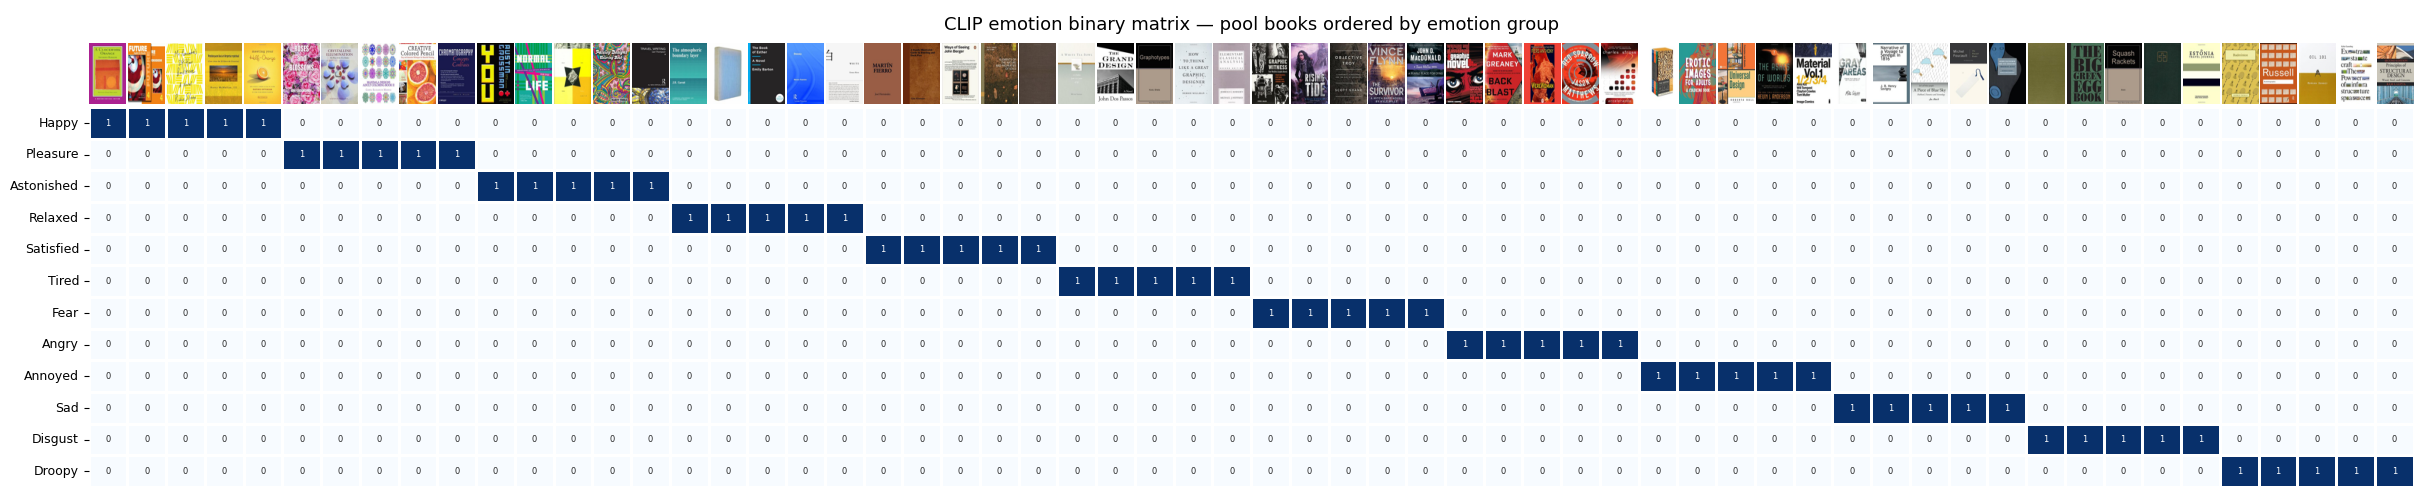

In [8]:
# CLIP emotion binary heatmap
plot_matrix_with_thumbs(
    clip_emotion_matrix, EMOTIONS, pool_image_paths, pool_emotions,
    'CLIP emotion binary matrix — pool books ordered by emotion group',
    cmap='Blues', fmt='', vmin=0, vmax=1, matrix_h=5.0,
    savefile='clip_emotion_binary_matrix.png'
)


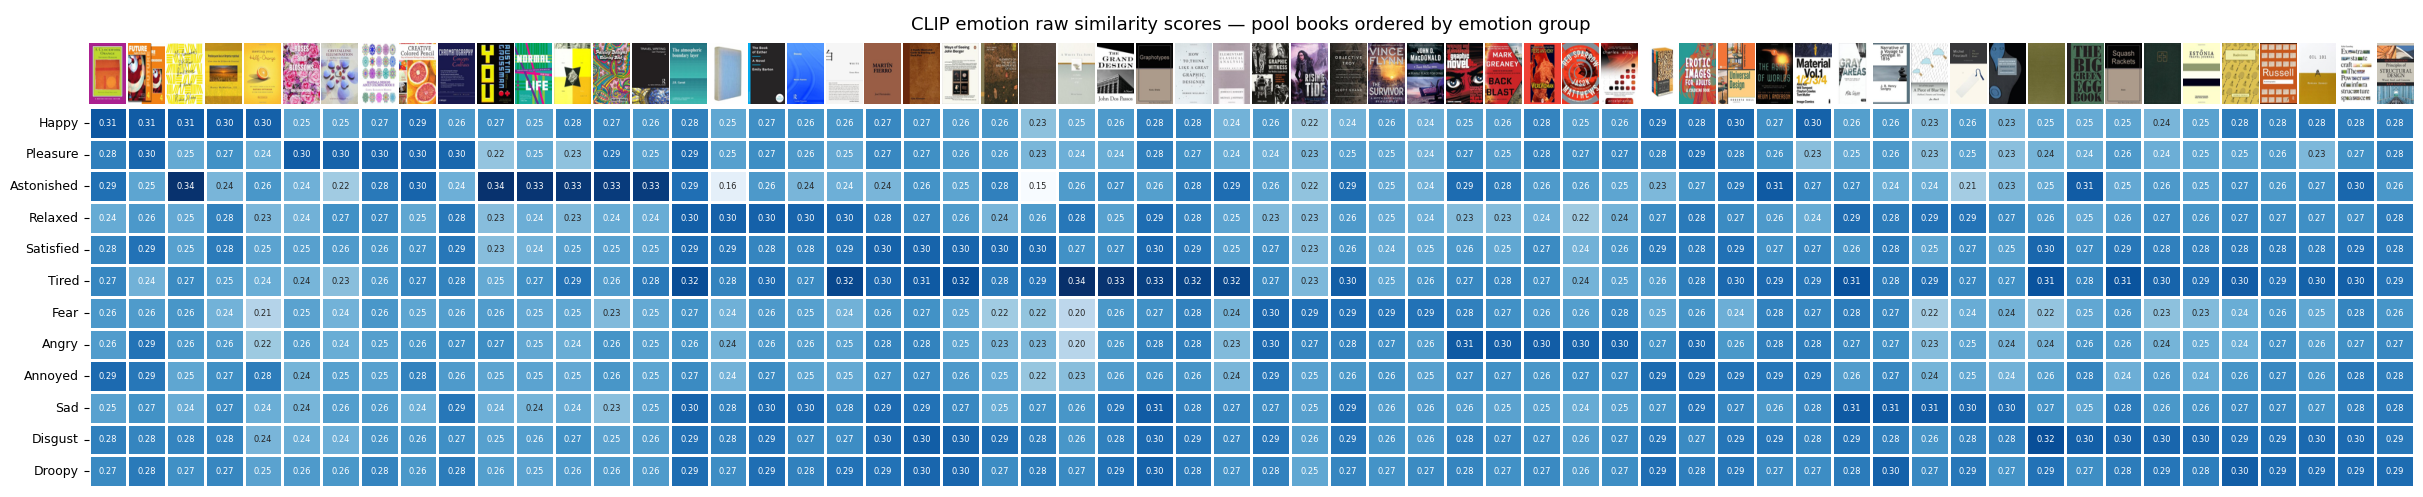

In [9]:
# CLIP emotion raw scores heatmap
plot_matrix_with_thumbs(
    clip_emotion_scores, EMOTIONS, pool_image_paths, pool_emotions,
    'CLIP emotion raw similarity scores — pool books ordered by emotion group',
    cmap='Blues', fmt='.2f', matrix_h=5.0,
    savefile='clip_emotion_raw_scores.png'
)


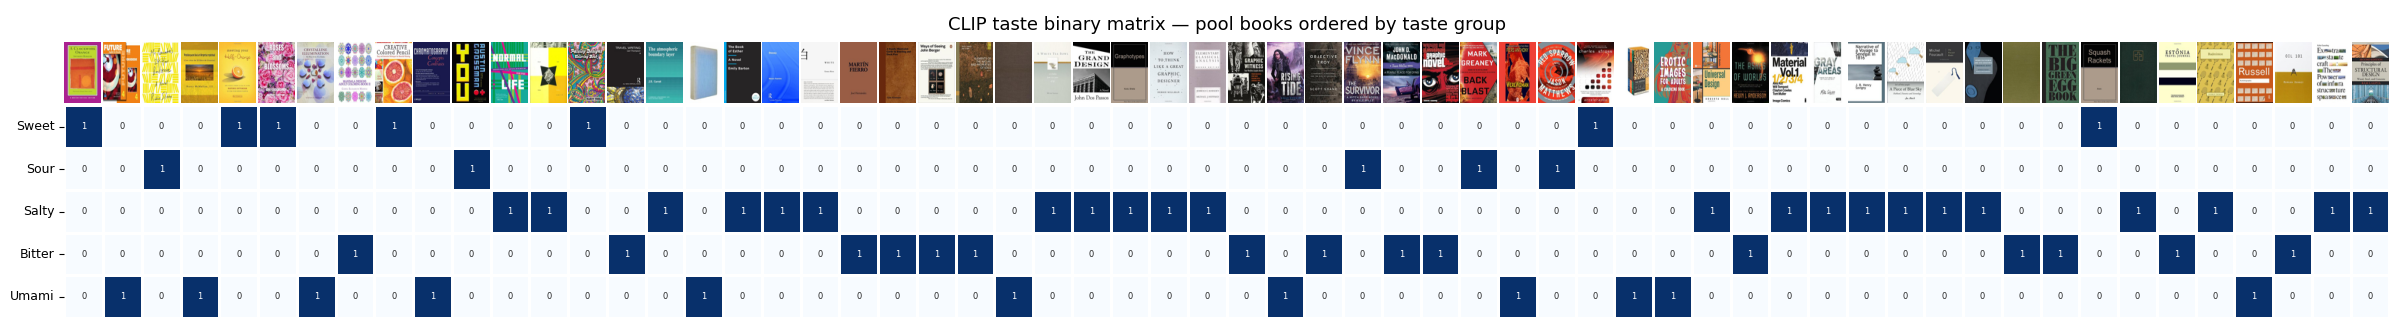

In [10]:
# CLIP taste binary heatmap

plot_matrix_with_thumbs(
    clip_taste_matrix,TASTES,pool_image_paths, pool_emotions,
    'CLIP taste binary matrix — pool books ordered by taste group',
    cmap='Blues', fmt='', vmin=0, vmax=1, matrix_h=2.8,
    savefile='clip_taste_binary_matrix.png'
)


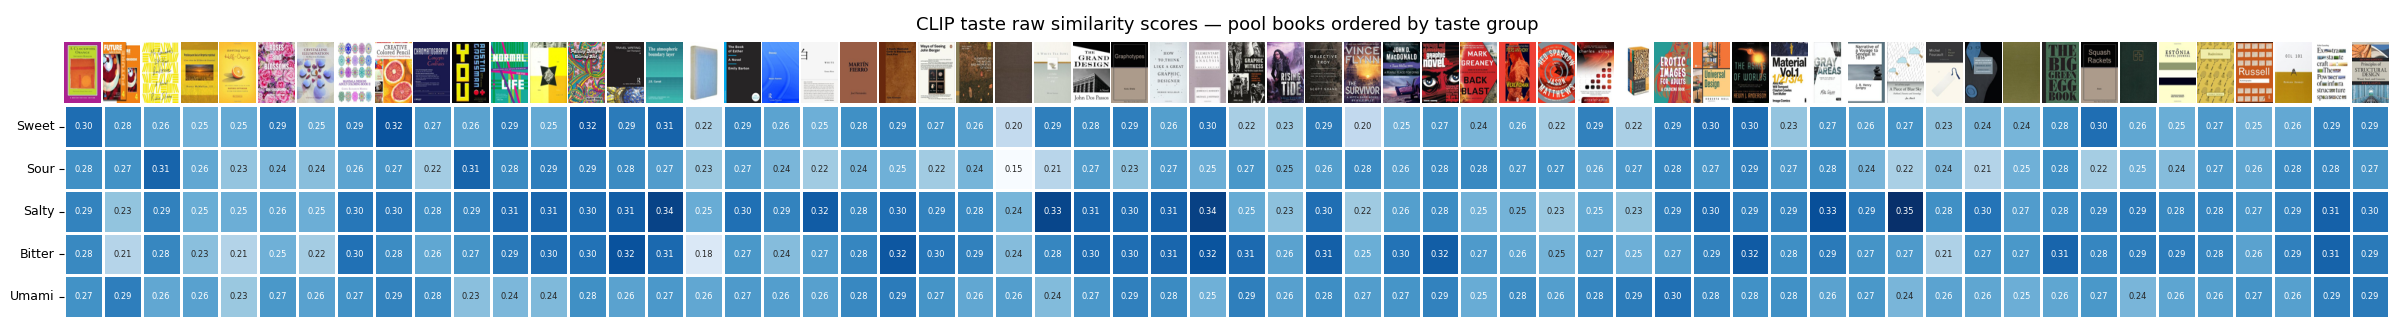

In [11]:
# CLIP taste raw scores heatmap

plot_matrix_with_thumbs(
    clip_taste_scores, TASTES, pool_image_paths, pool_emotions,
    'CLIP taste raw similarity scores — pool books ordered by taste group',
    cmap='Blues', fmt='.2f', matrix_h=2.8,
    savefile='clip_taste_raw_scores.png'
)


# Section 2 — Build human study matrices

- Load Conjointly Excel files
- Load mapping file (q_to_book_mapping.xlsx)
- load_plurality_votes() for emotion study
- load_plurality_votes() for taste study
- Join by book title using mapping file
- Build human binary emotion matrix (60×12)
- Build human binary taste matrix (60×5)
- Heatmap: human emotion
- Heatmap: human taste

In [12]:
# Load mapping
mapping    = pd.read_excel(MAPPING_FILE)
real_books = mapping[mapping['is_trial'] == 'No'].copy()

em_sorted = real_books.sort_values('emotion_Q (study 646348)').reset_index(drop=True)
ta_sorted = real_books.sort_values('taste_Q (study 646190)').reset_index(drop=True)

valid_emotion_qs = set(real_books['emotion_Q (study 646348)'].dropna().astype(int))
valid_taste_qs   = set(real_books['taste_Q (study 646190)'].dropna().astype(int))

print(f"Real books: {len(real_books)}")
print(f"Valid emotion Qs: {len(valid_emotion_qs)}, taste Qs: {len(valid_taste_qs)}")

Real books: 60
Valid emotion Qs: 60, taste Qs: 60


In [13]:
print('Loading emotion study...')
human_emotion_data = load_human_study(
    EMOTION_FILE, r'Book Cover Emotion Survey$',
    EMOTIONS_LOWER, valid_emotion_qs
)

print('Loading taste study...')
human_taste_data = load_human_study(
    TASTE_FILE, r'Book Cover Taste Association$',
    TASTES_LOWER, valid_taste_qs
)

Loading emotion study...
  Completed respondents: 62
  Total question columns found: 62
  Real book columns processed: 60 (skipped 2 trials/quality tests)
Loading taste study...
  Completed respondents: 56
  Total question columns found: 62
  Real book columns processed: 60 (skipped 2 trials/quality tests)


In [14]:
# Load mapping & build all human matrices
mapping    = pd.read_excel(MAPPING_FILE)
real_books = mapping[mapping['is_trial'] == 'No'].copy()

em_sorted = real_books.sort_values('emotion_Q (study 646348)').reset_index(drop=True)
ta_sorted = real_books.sort_values('taste_Q (study 646190)').reset_index(drop=True)

all_filenames = em_sorted['image_filename'].tolist()
fname_to_idx  = {f: i for i, f in enumerate(all_filenames)}
N_BOOKS       = len(all_filenames)

# Q number → result lookup
em_q_to_result = {b['q_num']: b for b in human_emotion_data}
ta_q_to_result = {b['q_num']: b for b in human_taste_data}

# Binary and probability matrices
human_emotion_matrix = np.zeros((N_BOOKS, len(EMOTIONS)), dtype=int)
human_taste_matrix   = np.zeros((N_BOOKS, len(TASTES)),   dtype=int)
human_emotion_probs  = np.zeros((N_BOOKS, len(EMOTIONS)), dtype=float)
human_taste_probs    = np.zeros((N_BOOKS, len(TASTES)),   dtype=float)

for i, row in em_sorted.iterrows():
    q_num = int(row['emotion_Q (study 646348)']) if pd.notna(row['emotion_Q (study 646348)']) else None
    row_i = fname_to_idx.get(row['image_filename'])
    if q_num is None or row_i is None: continue
    book = em_q_to_result.get(q_num)
    if book is None: continue
    human_emotion_probs[row_i] = book['probabilities']

    if book['vote_counts']:
        max_votes = max(book['vote_counts'].values())
        for label, count in book['vote_counts'].items():
            if count == max_votes:
                label_clean = label.lower().strip()
                if label_clean in EMOTIONS_LOWER:
                    human_emotion_matrix[row_i, EMOTIONS_LOWER.index(label_clean)] = 1

for i, row in ta_sorted.iterrows():
    q_num = int(row['taste_Q (study 646190)']) if pd.notna(row['taste_Q (study 646190)']) else None
    row_i = fname_to_idx.get(row['image_filename'])
    if q_num is None or row_i is None: continue
    book = ta_q_to_result.get(q_num)
    if book is None: continue
    human_taste_probs[row_i] = book['probabilities']

    if book['vote_counts']:
        max_votes = max(book['vote_counts'].values())
        for label, count in book['vote_counts'].items():
            if count == max_votes:
                label_clean = label.lower().strip()
                if label_clean in TASTES_LOWER:
                    human_taste_matrix[row_i, TASTES_LOWER.index(label_clean)] = 1

human_top1_emotion = [EMOTIONS[i] for i in human_emotion_probs.argmax(axis=1)]
human_top1_taste   = [TASTES[i]   for i in human_taste_probs.argmax(axis=1)]

# \Sort by filename group order (0_r1 … 11_r5)
def _sort_df(df):
    d = df.copy()
    d['_sort'] = d['image_filename'].apply(sort_key)
    return d.sort_values('_sort').reset_index(drop=True)

em_sorted_by_group = _sort_df(em_sorted)
ta_sorted_by_group = _sort_df(ta_sorted)

em_col_order = [fname_to_idx[r['image_filename']]
                for _, r in em_sorted_by_group.iterrows()
                if r['image_filename'] in fname_to_idx]
ta_col_order = [fname_to_idx[r['image_filename']]
                for _, r in ta_sorted_by_group.iterrows()
                if r['image_filename'] in fname_to_idx]

emotion_matrix_sorted = human_emotion_matrix[em_col_order, :]
taste_matrix_sorted   = human_taste_matrix[ta_col_order, :]

human_emotion_image_paths = [resolve_path(r['image_filename'])
                              for _, r in em_sorted_by_group.iterrows()]
human_taste_image_paths   = [resolve_path(r['image_filename'])
                              for _, r in ta_sorted_by_group.iterrows()]

def _border(df):
    if 'clip_emotion' in df.columns:
        return [str(r.get('clip_emotion','')).lower() for _, r in df.iterrows()]
    return [''] * len(df)

em_border = _border(em_sorted_by_group)
ta_border = _border(ta_sorted_by_group)

print(f'N_BOOKS:             {N_BOOKS}')
print(f'emotion_matrix:      {human_emotion_matrix.shape}')
print(f'taste_matrix:        {human_taste_matrix.shape}')
print(f'human_emotion_probs: {human_emotion_probs.shape}')
print(f'human_taste_probs:   {human_taste_probs.shape}')
print(f'em images resolved:  {sum(1 for p in human_emotion_image_paths if p)}/{N_BOOKS}')
print(f'ta images resolved:  {sum(1 for p in human_taste_image_paths   if p)}/{N_BOOKS}')

N_BOOKS:             60
emotion_matrix:      (60, 12)
taste_matrix:        (60, 5)
human_emotion_probs: (60, 12)
human_taste_probs:   (60, 5)
em images resolved:  60/60
ta images resolved:  60/60


In [15]:
#  aliugnemnt bridge to make sure that im coparing the SAME book for both CLIP and human data
# why need this alignement? if dh then i might be just comparing random books together
human_fname_to_idx = {f: i for i, f in enumerate(all_filenames)}


isbn_to_human_idx = {} # isbn to human matrix row
for _, row in real_books.iterrows():
    isbn = str(row['book_name']).strip()
    fname = str(row['image_filename']).strip()
    h_idx = human_fname_to_idx.get(fname)
    if h_idx is not None:
        isbn_to_human_idx[isbn] = h_idx

isbn_to_clip_idx = {} # isbn to clip matrix
for i, entry in enumerate(pool_entries):
    isbn = str(entry['fname']).strip()
    isbn_to_clip_idx[isbn] = i

# These then use the `book_name` column that i've newly added to the mapping file to create a shared ISBN key that both sides understand.

print(f"isbn_to_human_idx: {len(isbn_to_human_idx)} entries")
print(f"isbn_to_clip_idx:  {len(isbn_to_clip_idx)} entries")

# Find common ISBNs: expected all 60 books if the mapping is complete and accurate
common_isbns = [isbn for isbn in isbn_to_clip_idx if isbn in isbn_to_human_idx]
print(f"Common ISBNs:      {len(common_isbns)}")

# Build aligned matrices

# for each common isbn,  pull the correspoinding row from the CLIP matrix and the corresponding row from the human matrix and stacks them into new arrays
# the result is that row i in clip_em_aligned and row i in human_em_aligned are now guaranteed to be the same book

clip_em_aligned  = np.array([clip_emotion_probs [isbn_to_clip_idx[isbn]]  for isbn in common_isbns])
clip_ta_aligned  = np.array([clip_taste_probs   [isbn_to_clip_idx[isbn]]  for isbn in common_isbns])
human_em_aligned = np.array([human_emotion_probs[isbn_to_human_idx[isbn]] for isbn in common_isbns])
human_ta_aligned = np.array([human_taste_probs  [isbn_to_human_idx[isbn]] for isbn in common_isbns])

clip_bin_em_aligned  = np.array([clip_emotion_matrix[isbn_to_clip_idx[isbn]]  for isbn in common_isbns])
clip_bin_ta_aligned  = np.array([clip_taste_matrix  [isbn_to_clip_idx[isbn]]  for isbn in common_isbns])
human_bin_em_aligned = np.array([human_emotion_matrix     [isbn_to_human_idx[isbn]] for isbn in common_isbns])
human_bin_ta_aligned = np.array([human_taste_matrix       [isbn_to_human_idx[isbn]] for isbn in common_isbns])

N_common = len(common_isbns)
print(f"\nFinal aligned matrix shapes:")
print(f"  clip_em_aligned:  {clip_em_aligned.shape}")
print(f"  human_em_aligned: {human_em_aligned.shape}")
print(f"  clip_ta_aligned:  {clip_ta_aligned.shape}")
print(f"  human_ta_aligned: {human_ta_aligned.shape}")

isbn_to_human_idx: 60 entries
isbn_to_clip_idx:  60 entries
Common ISBNs:      60

Final aligned matrix shapes:
  clip_em_aligned:  (60, 12)
  human_em_aligned: (60, 12)
  clip_ta_aligned:  (60, 5)
  human_ta_aligned: (60, 5)


In [16]:
# For each book in the CLIP pool order, get the corresponding human row
clip_ordered_human_em = np.array([
    human_emotion_probs[isbn_to_human_idx[isbn]]
    for isbn in [str(e['fname']).strip() for e in pool_entries]
    if isbn in isbn_to_human_idx
])

clip_ordered_human_ta = np.array([
    human_taste_probs[isbn_to_human_idx[isbn]]
    for isbn in [str(e['fname']).strip() for e in pool_entries]
    if isbn in isbn_to_human_idx
])

# Image paths in CLIP pool order
clip_ordered_human_img = [
    resolve_path(all_filenames[isbn_to_human_idx[isbn]])
    for isbn in [str(e['fname']).strip() for e in pool_entries]
    if isbn in isbn_to_human_idx
]

# Border colours in CLIP pool order
clip_ordered_em_border = [
    pool_emotions[i] for i, e in enumerate(pool_entries)
    if str(e['fname']).strip() in isbn_to_human_idx
]

clip_ordered_human_em_binary = np.array([
    human_emotion_matrix[isbn_to_human_idx[isbn]]
    for isbn in [str(e['fname']).strip() for e in pool_entries]
    if isbn in isbn_to_human_idx
])

clip_ordered_human_ta_binary = np.array([
    human_taste_matrix[isbn_to_human_idx[isbn]]
    for isbn in [str(e['fname']).strip() for e in pool_entries]
    if isbn in isbn_to_human_idx
])

# Taste borders
clip_ordered_ta_border = [
    e['clip_taste'] for e in pool_entries
    if str(e['fname']).strip() in isbn_to_human_idx
]

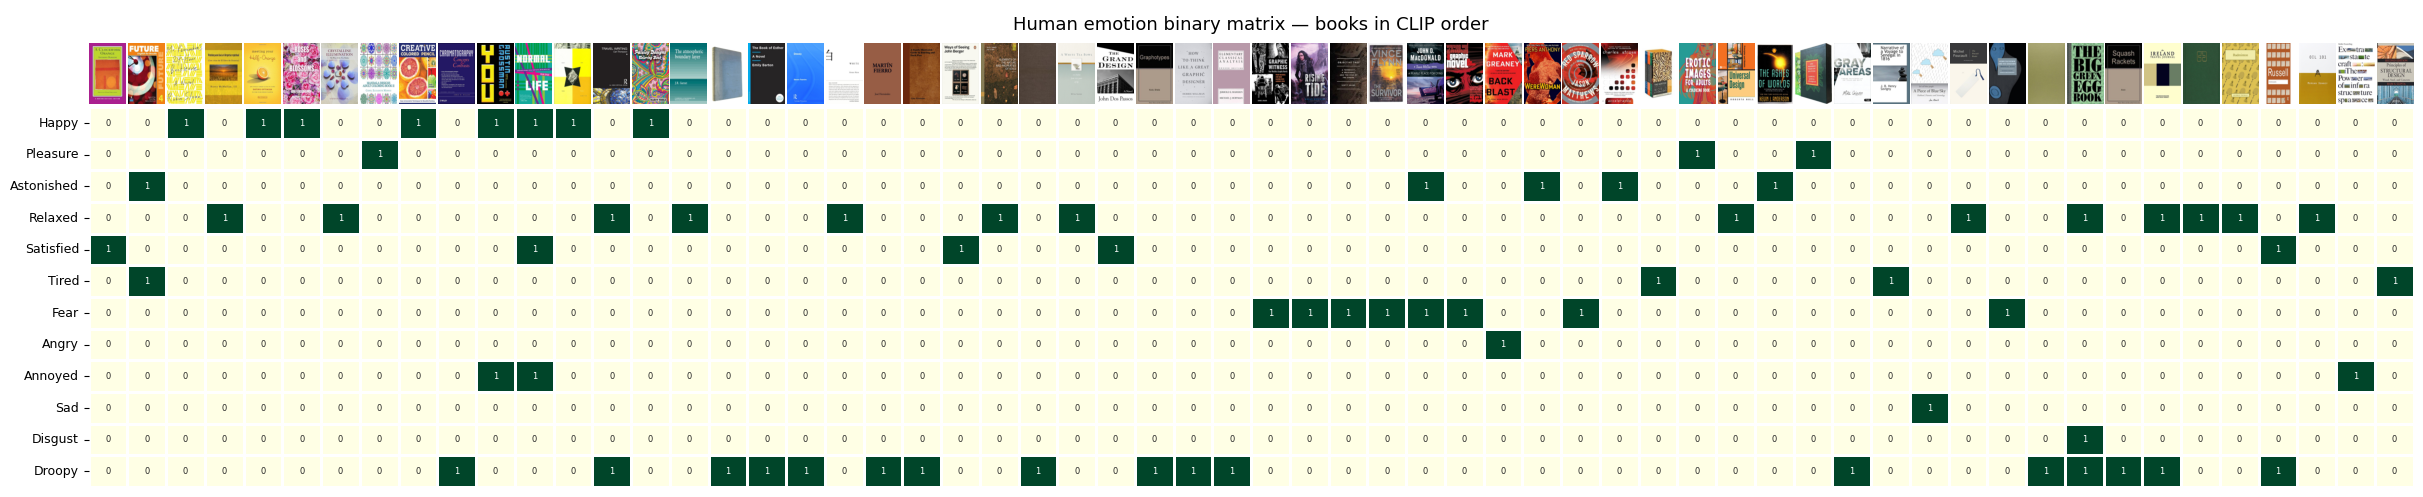

In [17]:
# Human emotion binary heatmap
plot_matrix_with_thumbs(
    clip_ordered_human_em_binary, EMOTIONS,
    clip_ordered_human_img, clip_ordered_em_border,
    'Human emotion binary matrix — books in CLIP order',
    cmap='YlGn', fmt='d', vmin=0, vmax=1, matrix_h=5.0,
    savefile='human_emotion_binary_CLIP_order.png'
)

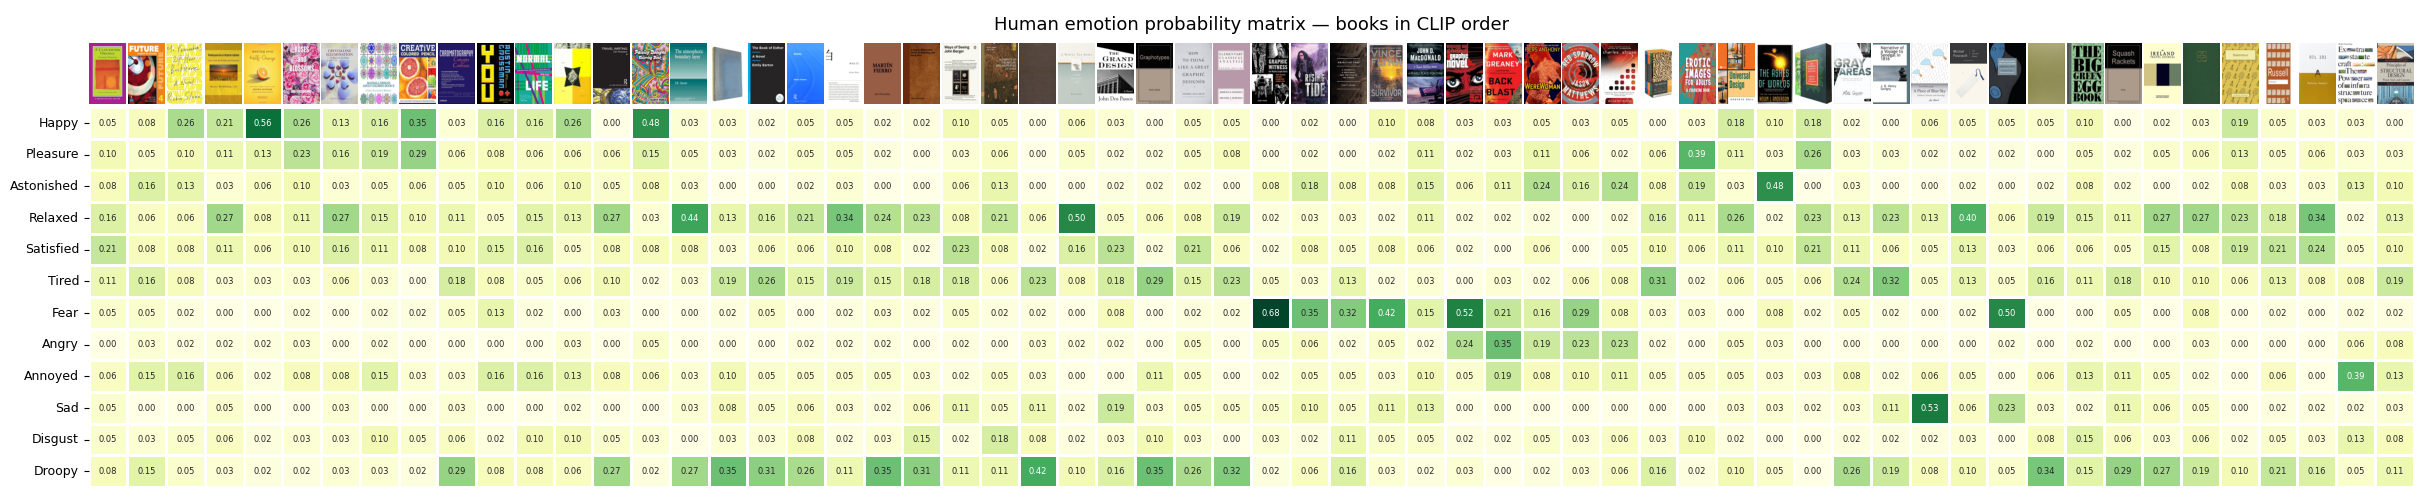

In [18]:
# Human emotion probability heatmap
plot_matrix_with_thumbs(
    clip_ordered_human_em, EMOTIONS,
    clip_ordered_human_img, clip_ordered_em_border,
    'Human emotion probability matrix — books in CLIP order',
    cmap='YlGn', fmt='.2f', matrix_h=5.0,
    savefile='human_emotion_prob_CLIP_order.png'
)

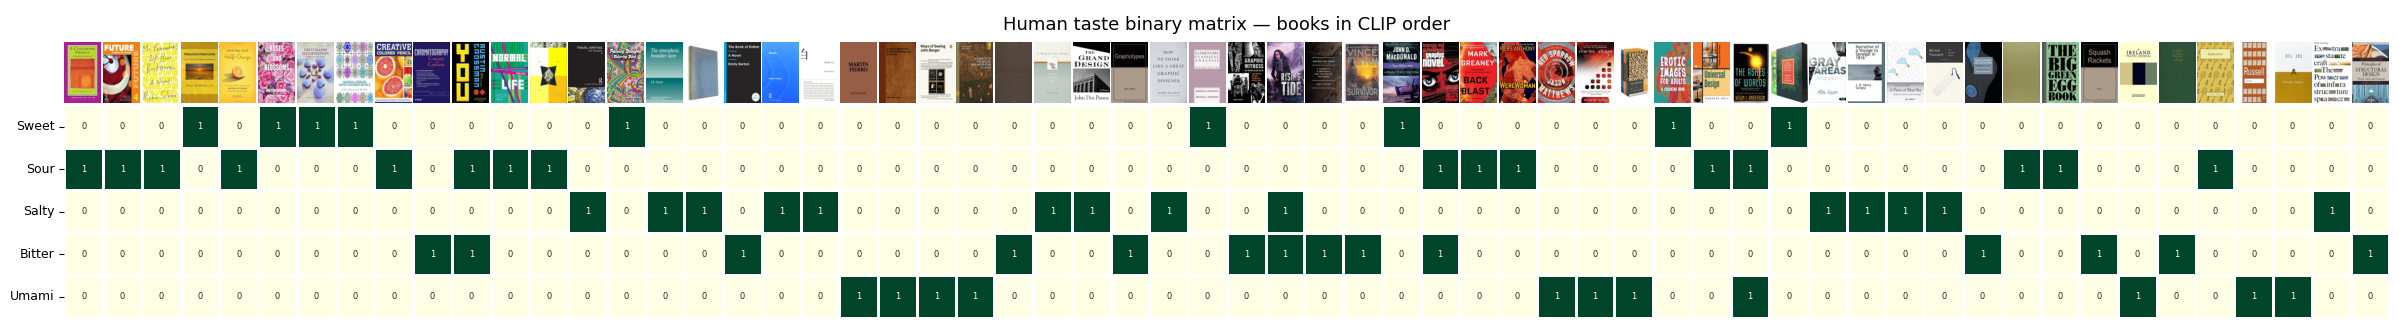

In [19]:
# Human taste binary heatmap
plot_matrix_with_thumbs(
    clip_ordered_human_ta_binary, TASTES,
    clip_ordered_human_img, clip_ordered_ta_border,
    'Human taste binary matrix — books in CLIP order',
    cmap='YlGn', fmt='d', vmin=0, vmax=1, matrix_h=2.8,
    savefile='human_taste_binary_CLIP_order.png'
)

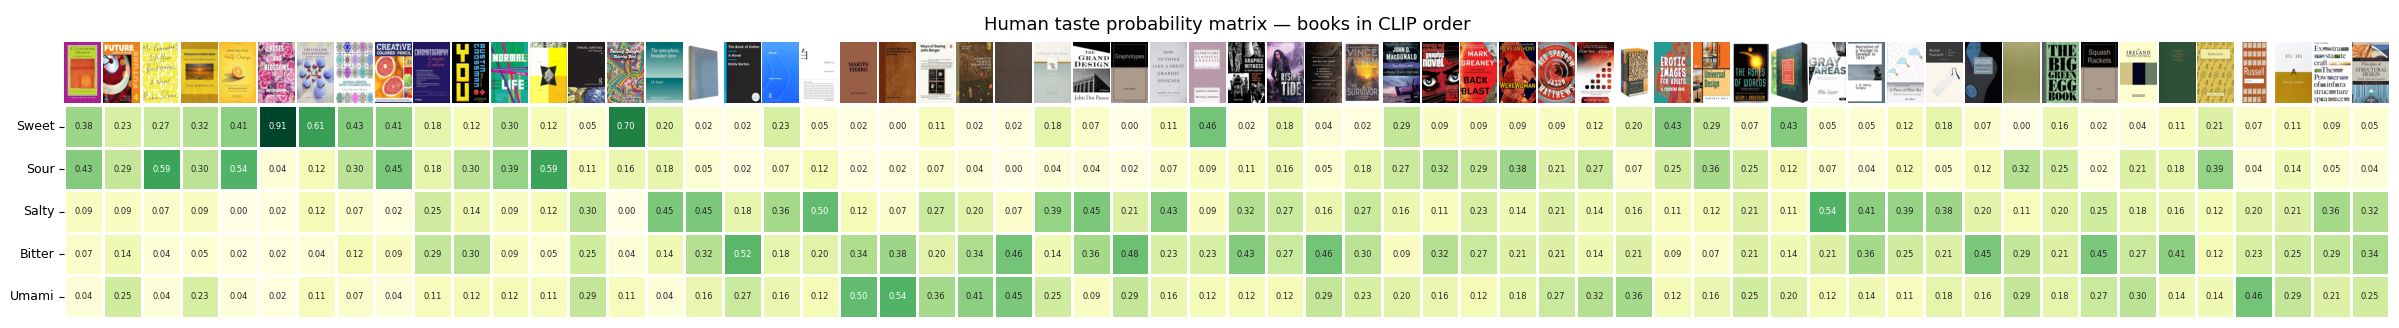

In [20]:
# Human taste prob heatmap
plot_matrix_with_thumbs(
    clip_ordered_human_ta, TASTES,
    clip_ordered_human_img, clip_ordered_ta_border,
    'Human taste probability matrix — books in CLIP order',
    cmap='YlGn', fmt='.2f', matrix_h=2.8,
    savefile='human_taste_prob_CLIP_order.png'
)

In [43]:
# Statistical Validation: Response Distribution + Chi-Square GOF
from scipy.stats import chisquare
from statsmodels.stats.multitest import multipletests

def build_distribution_matrix(q_to_result, label_list, sorted_df, q_col, fname_to_idx):
    """
    Build the full response distribution matrix (n_books × n_labels)
    and run chi-square goodness-of-fit per book.
    """
    n_labels = len(label_list)
    proportion_rows = []
    count_rows = []
    filenames = []
    chi2_vals, p_vals, n_votes_list = [], [], []
    top1_labels = []

    for _, r in sorted_df.iterrows():
        q_num = int(r[q_col]) if pd.notna(r[q_col]) else None
        if q_num is None:
            continue
        book = q_to_result.get(q_num)
        if book is None:
            continue

        counts = np.array([book['vote_counts'].get(lab, 0)
                           for lab in label_list], dtype=float)
        n = counts.sum()
        if n == 0:
            continue

        proportions = counts / n
        stat, p = chisquare(counts)

        proportion_rows.append(proportions)
        count_rows.append(counts)
        filenames.append(r['image_filename'])
        chi2_vals.append(stat)
        p_vals.append(p)
        n_votes_list.append(int(n))
        top1_labels.append(label_list[np.argmax(counts)])

    _, p_corr, _, _ = multipletests(p_vals, method='fdr_bh')

    return {
        'proportions': np.array(proportion_rows),
        'counts':      np.array(count_rows),
        'filenames':   filenames,
        'chi2':        np.array(chi2_vals),
        'p_corrected': p_corr,
        'n_votes':     n_votes_list,
        'top1':        top1_labels,
    }

dist_emotion = build_distribution_matrix(
    em_q_to_result, EMOTIONS_LOWER, em_sorted,
    'emotion_Q (study 646348)', fname_to_idx
)
dist_taste = build_distribution_matrix(
    ta_q_to_result, TASTES_LOWER, ta_sorted,
    'taste_Q (study 646190)', fname_to_idx
)

for name, d in [('Emotion', dist_emotion), ('Taste', dist_taste)]:
    n_sig = (d['p_corrected'] < 0.05).sum()
    print(f"{name}: {n_sig}/{len(d['filenames'])} books show significant "
          f"non-uniform distributions (χ² GOF, FDR-corrected p < 0.05)")

Emotion: 59/60 books show significant non-uniform distributions (χ² GOF, FDR-corrected p < 0.05)
Taste: 50/60 books show significant non-uniform distributions (χ² GOF, FDR-corrected p < 0.05)


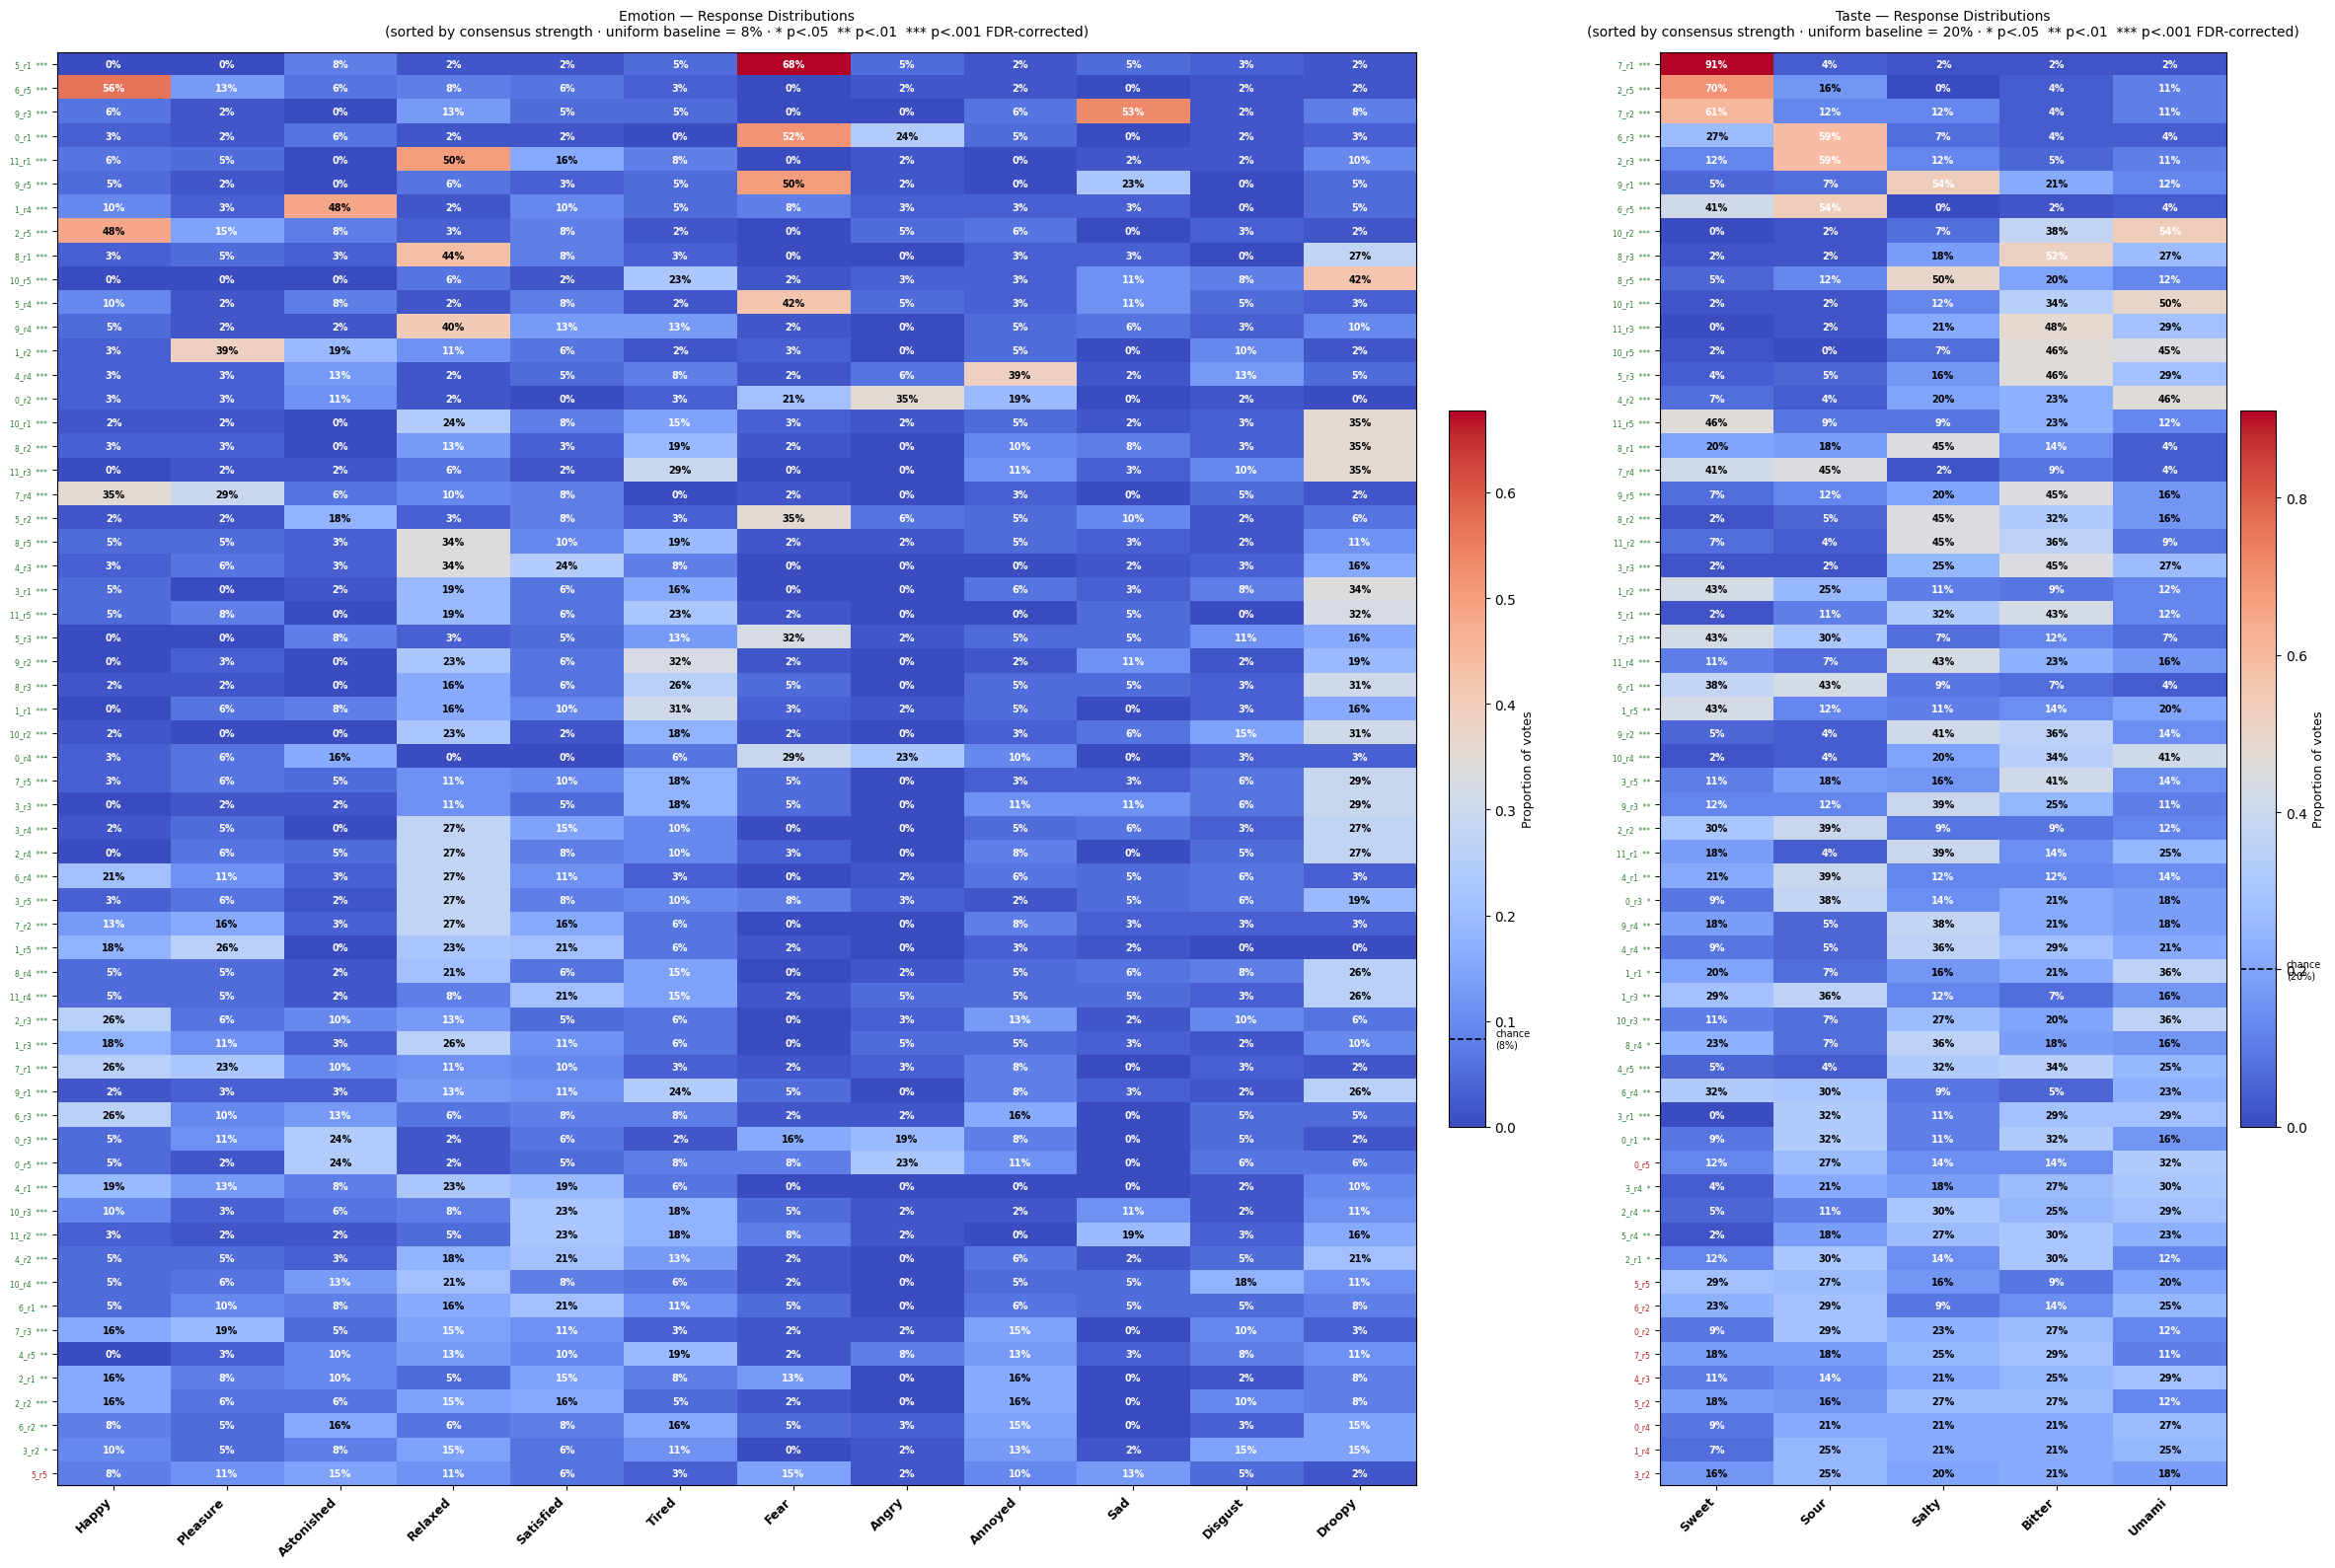


Emotion:
  Significant books: 59/60
  Highest consensus: 68%
  Mean top-1 proportion: 32%
  Books with majority vote (>50%): 4/60

Taste:
  Significant books: 50/60
  Highest consensus: 91%
  Mean top-1 proportion: 41%
  Books with majority vote (>50%): 9/60


In [50]:
# Heatmap: Response distributions sorted by consensus strength
# What this shows:
#   - Human consensus structure: dark cells = strong agreement on a label
#   - Ambiguity: rows with spread-out colour = no clear winner
#   - Cross-sensory behaviour: which taste/emotion clusters co-occur
#   - Significance: stars on y-axis from chi-square GOF (FDR-corrected)

fig, axes = plt.subplots(1, 2, figsize=(24, 16),
                         gridspec_kw={'width_ratios': [12, 5]})

for ax, (title, dist, labels, palette) in zip(axes, [
    ('Emotion', dist_emotion, EMOTIONS, EMOTION_COLORS),
    ('Taste',   dist_taste,   TASTES,
     {k.lower(): v for k, v in TASTE_PALETTE.items()}),
]):
    props   = dist['proportions']
    fnames  = dist['filenames']
    chi2    = dist['chi2']
    pcorr   = dist['p_corrected']
    top1    = dist['top1']
    n_books, n_labels = props.shape

    # Sort by max proportion (strongest consensus at top)
    max_prop = props.max(axis=1)
    order = np.argsort(-max_prop)

    props_sorted  = props[order]
    fnames_sorted = [fnames[i] for i in order]
    pcorr_sorted  = pcorr[order]
    top1_sorted   = [top1[i] for i in order]

    # Y-axis labels with significance stars
    ylabels = []
    for f, p in zip(fnames_sorted, pcorr_sorted):
        stars = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
        ylabels.append(f'{f}  {stars}'.strip())

    # Uniform baseline
    baseline = 1.0 / n_labels

    # Plot heatmap
    im = ax.imshow(props_sorted, cmap='coolwarm', aspect='auto',
                   vmin=0, vmax=props_sorted.max())

    ax.set_xticks(range(n_labels))
    ax.set_xticklabels([l.capitalize() for l in labels] if isinstance(labels[0], str)
                       and labels[0][0].islower() else labels,
                       rotation=45, ha='right', fontsize=9, fontweight='bold')
    ax.set_yticks(range(n_books))
    ax.set_yticklabels(ylabels, fontsize=5.5)

    # Annotate cells
    for i in range(n_books):
        for j in range(n_labels):
            val = props_sorted[i, j]
            is_max = (val == props_sorted[i].max()) and val > 0
            if val > 0.5:
                color = 'white'
            elif val < 0.15:
                color = 'white'
            else:
                color = 'black'
            weight = 'bold'
            ax.text(j, i, f'{val:.0%}', ha='center', va='center',
                    fontsize=7, color=color, fontweight=weight)

    # Draw baseline reference line annotation
    ax.set_title(
        f'{title} — Response Distributions\n'
        f'(sorted by consensus strength · uniform baseline = {baseline:.0%} · '
        f'* p<.05  ** p<.01  *** p<.001 FDR-corrected)',
        fontsize=10, pad=12
    )

    # Colour the y-tick labels by significance
    for tick_label, p in zip(ax.get_yticklabels(), pcorr_sorted):
        if p < 0.05:
            tick_label.set_color('#2e7d32')
        else:
            tick_label.set_color('#b71c1c')

    cbar = plt.colorbar(im, ax=ax, shrink=0.5, pad=0.02)
    cbar.set_label('Proportion of votes', fontsize=9)

    # Add a dashed line in the colorbar at the uniform baseline
    cbar.ax.axhline(baseline, color='black', linestyle='--', linewidth=1.2)
    cbar.ax.text(1.3, baseline, f'chance\n({baseline:.0%})',
                 transform=cbar.ax.get_yaxis_transform(),
                 fontsize=7, va='center')

plt.tight_layout()
plt.savefig('human_response_distribution_heatmap.png', dpi=200, bbox_inches='tight')
plt.show()

# Summary
for name, dist in [('Emotion', dist_emotion), ('Taste', dist_taste)]:
    n_sig = (dist['p_corrected'] < 0.05).sum()
    max_consensus = dist['proportions'].max(axis=1)
    print(f"\n{name}:")
    print(f"  Significant books: {n_sig}/{len(dist['filenames'])}")
    print(f"  Highest consensus: {max_consensus.max():.0%}")
    print(f"  Mean top-1 proportion: {max_consensus.mean():.0%}")
    print(f"  Books with majority vote (>50%): "
          f"{(max_consensus > 0.5).sum()}/{len(dist['filenames'])}")

# Section 3 — t-SNE visualisations

In [21]:
# Pre-cache all thumbnails at small size
thumbnail_cache = {}

all_paths = set(
    [p for p in pool_image_paths          if p] +
    [p for p in human_emotion_image_paths if p] +
    [p for p in human_taste_image_paths   if p]
)

for path in all_paths:
    if os.path.exists(path):
        try:
            img = Image.open(path).convert('RGB')
            img.thumbnail((20, 30))
            thumbnail_cache[path] = np.array(img)
        except:
            pass

print(f'Cached {len(thumbnail_cache)} thumbnails')

Cached 120 thumbnails


In [22]:
# Run t-SNE and plot with book cover thumbnails
def run_tsne(matrix, perplexity=10, random_state=42):
    return TSNE(n_components=2, perplexity=perplexity,
                random_state=random_state, max_iter=1000).fit_transform(matrix)

coords_clip_em  = run_tsne(clip_emotion_probs)
coords_clip_ta  = run_tsne(clip_taste_probs)
coords_human_em = run_tsne(human_emotion_probs)
coords_human_ta = run_tsne(human_taste_probs)


Saved: tsne_clip_emotion.png


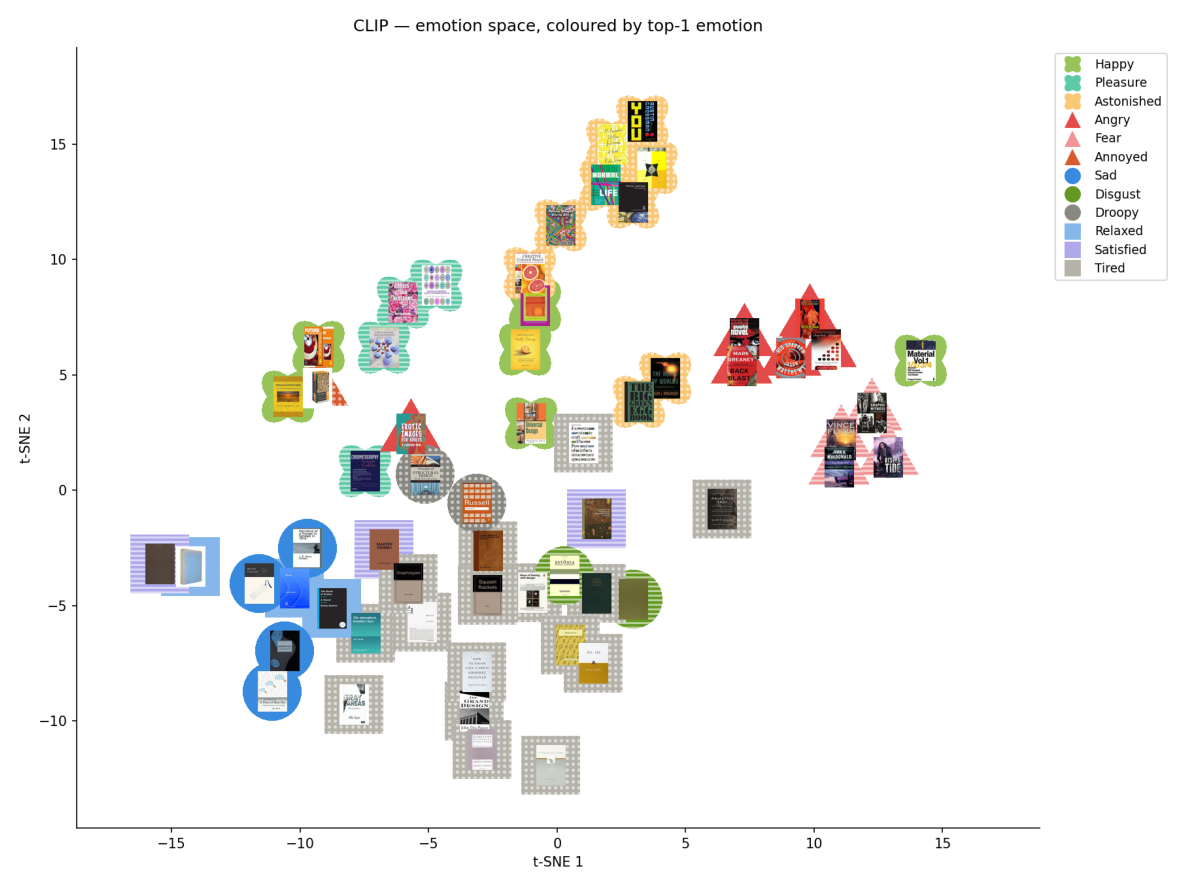

In [23]:
# CLIP on emotion space (coloured by top-1 taste → taste shapes)
tsne_with_covers(coords_clip_em, clip_top1_emotion, EMOTION_PALETTE,
                     'CLIP — emotion space, coloured by top-1 emotion',
                     pool_image_paths,
                     savefile='tsne_clip_emotion.png',
                     shape_map=EMOTION_SHAPE,
                 pattern_map=EMOTION_PATTERN)


Saved: tsne_human_emotion.png


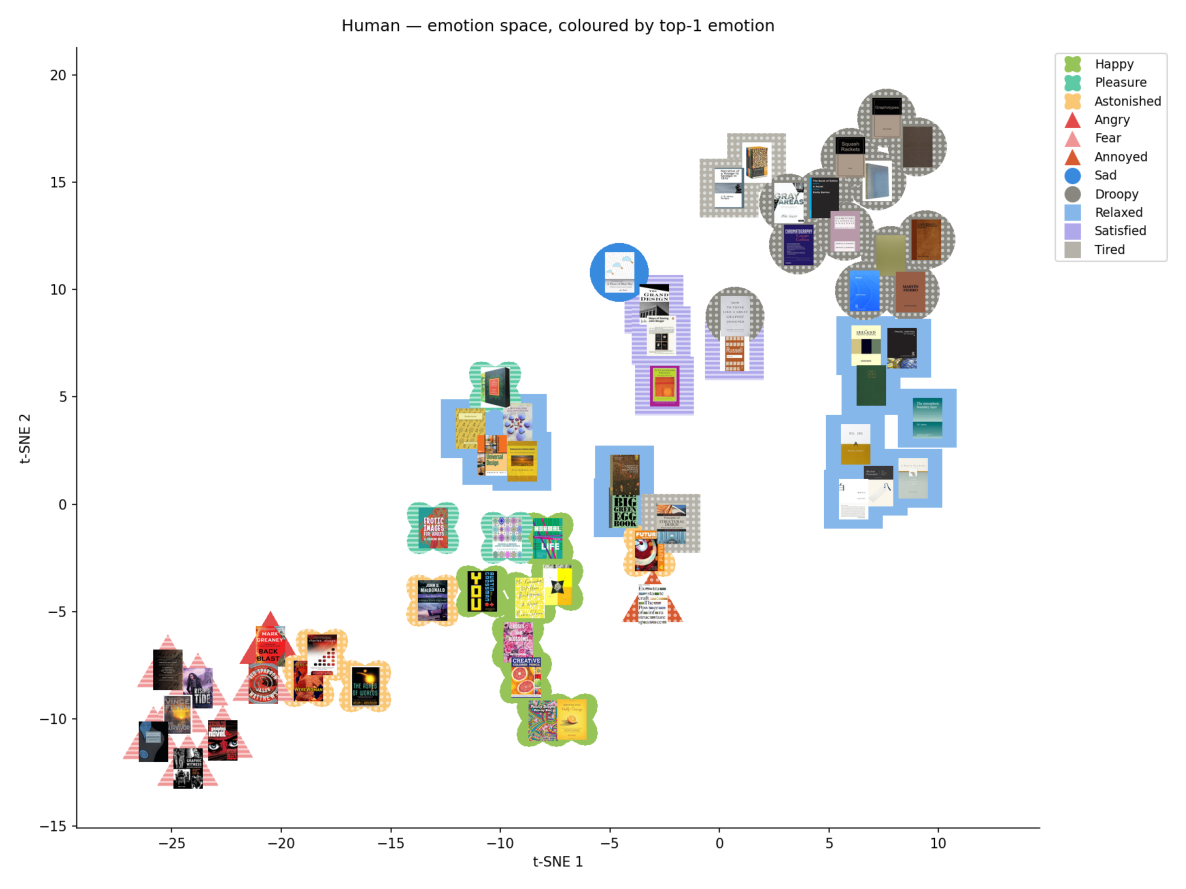

In [24]:
# Human study on emotion space (coloured by top-1 emotion → shapes + pattern)
human_em_tsne_paths = [resolve_path(f) for f in all_filenames]

tsne_with_covers(coords_human_em, human_top1_emotion, EMOTION_PALETTE,
                 'Human — emotion space, coloured by top-1 emotion',
                 human_em_tsne_paths,
                 savefile='tsne_human_emotion.png',
                 shape_map=EMOTION_SHAPE,
                 pattern_map=EMOTION_PATTERN)


Saved: tsne_clip_taste.png


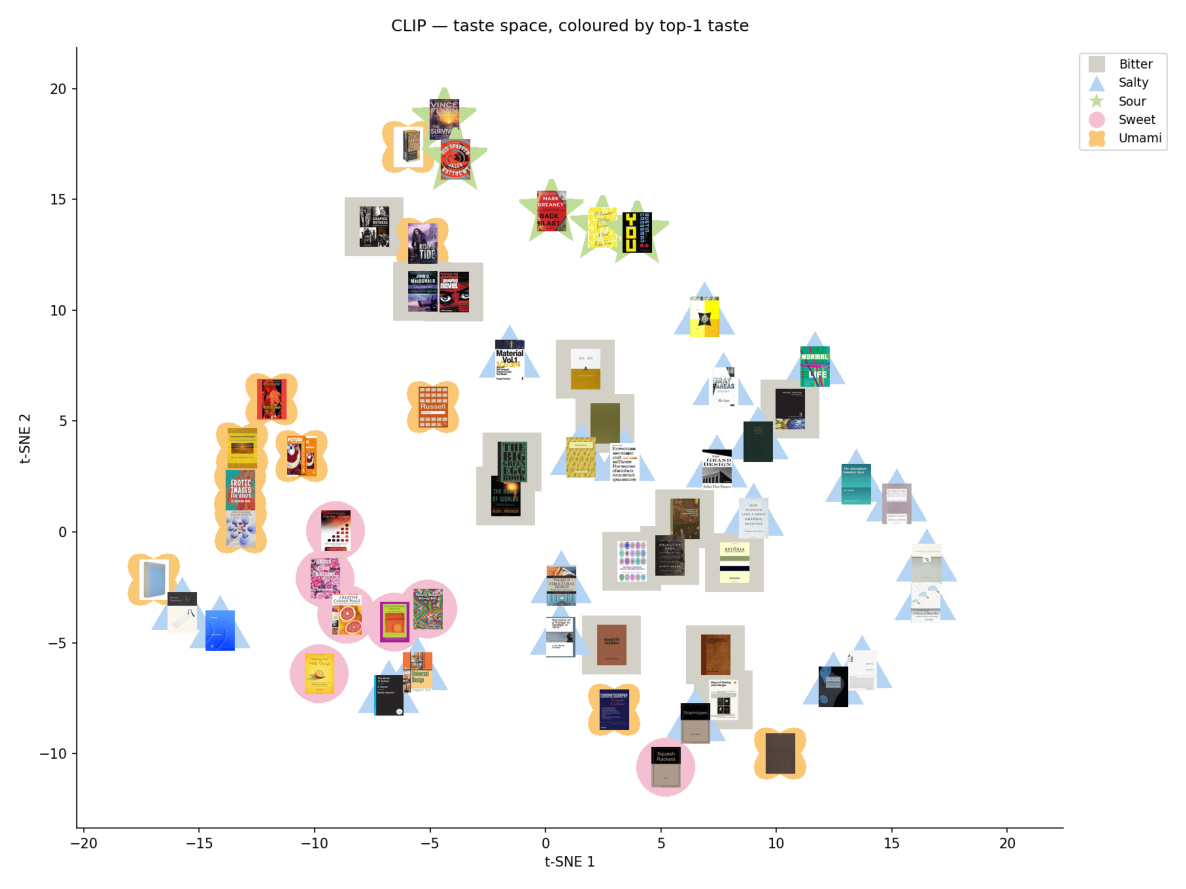

In [25]:
# CLIP on taste space (coloured by top-1 emotion → emotion shapes + patterns)


tsne_with_covers(coords_clip_ta, clip_top1_taste, TASTE_PALETTE,
                     'CLIP — taste space, coloured by top-1 taste',
                     pool_image_paths,
                     savefile='tsne_clip_taste.png',
                     shape_map=TASTE_SHAPE)


Saved: tsne_human_taste.png


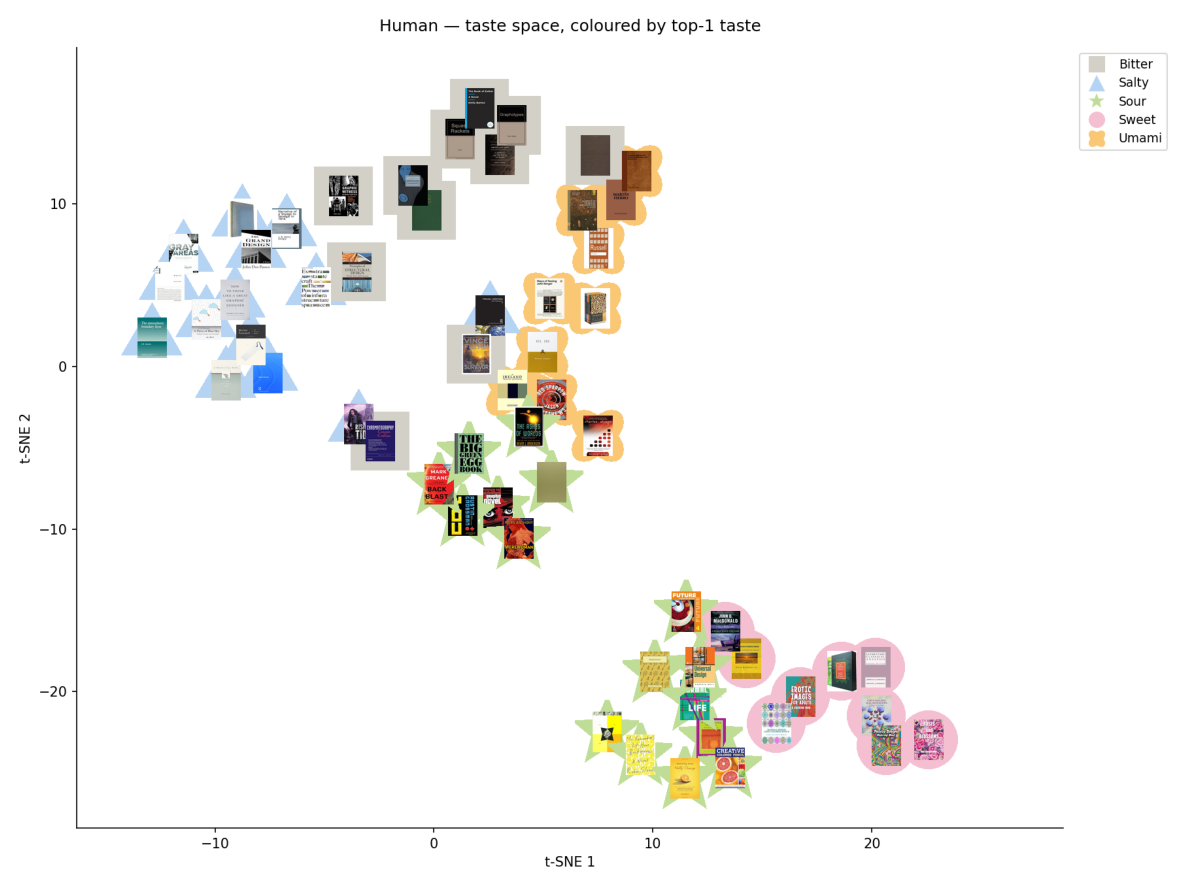

In [26]:
# Human study on taste space (coloured by top-1 taste)
human_ta_tsne_paths = [resolve_path(f) for f in all_filenames]

tsne_with_covers(coords_human_ta, human_top1_taste, TASTE_PALETTE,
                 'Human — taste space, coloured by top-1 taste',
                 human_ta_tsne_paths,
                 savefile='tsne_human_taste.png',
                 shape_map=TASTE_SHAPE)


# Section 4 - Valence Arousal Space

In [27]:
# VA coordinates (integer scale, from Russell circumplex diagram)
VA = {
    'astonished': ( 1,  3),
    'happy':      ( 2,  2),
    'pleasure':   ( 3,  1),
    'satisfied':   ( 3, -1),
    'relaxed':    ( 2, -2),
    'tired':      ( 1, -3),
    'droopy':     (-1, -3),
    'disgust':    (-2, -2),
    'sad':        (-3, -1),
    'annoyed':    (-3,  1),
    'angry':      (-2,  2),
    'fear':       (-1,  3),
}

va_coords = np.array([VA[e] for e in EMOTIONS_LOWER])  # (12, 2)

# Project each book into VA space using score distribution as weights
clip_va  = clip_emotion_probs  @ va_coords   # (60, 2)
human_va = human_emotion_probs @ va_coords   # (60, 2)

print(f'clip_va shape:  {clip_va.shape}')
print(f'human_va shape: {human_va.shape}')
print(f'Valence range  — CLIP:  [{clip_va[:,0].min():.2f}, {clip_va[:,0].max():.2f}]')
print(f'Arousal range  — CLIP:  [{clip_va[:,1].min():.2f}, {clip_va[:,1].max():.2f}]')
print(f'Valence range  — Human: [{human_va[:,0].min():.2f}, {human_va[:,0].max():.2f}]')
print(f'Arousal range  — Human: [{human_va[:,1].min():.2f}, {human_va[:,1].max():.2f}]')




clip_va shape:  (60, 2)
human_va shape: (60, 2)
Valence range  — CLIP:  [-0.13, 0.10]
Arousal range  — CLIP:  [-0.29, 0.13]
Valence range  — Human: [-1.27, 2.11]
Arousal range  — Human: [-2.21, 2.18]


Saved: va_clip_taste.png


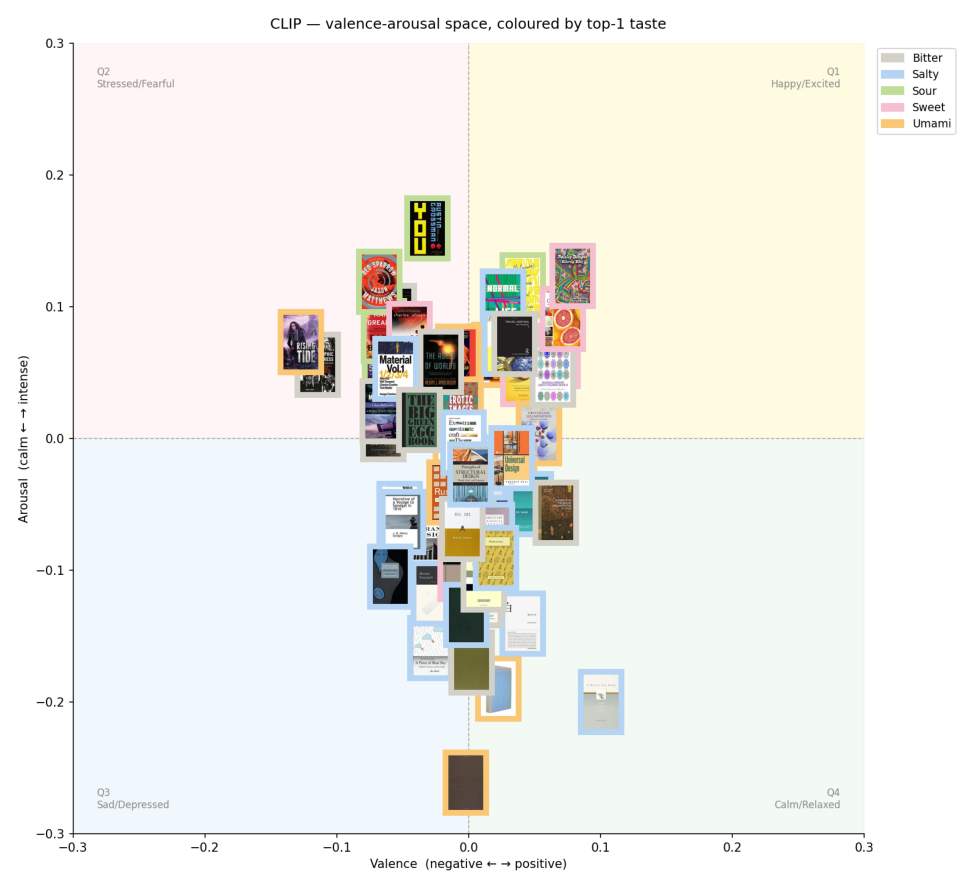

In [28]:
# VA plot 1: CLIP, coloured by taste
plot_va_covers(
    clip_va, clip_top1_taste,
    TASTE_PALETTE,
    'CLIP — valence-arousal space, coloured by top-1 taste',
    pool_image_paths,
    savefile='va_clip_taste.png',
    force_lim=0.3
)

Saved: va_human_taste.png


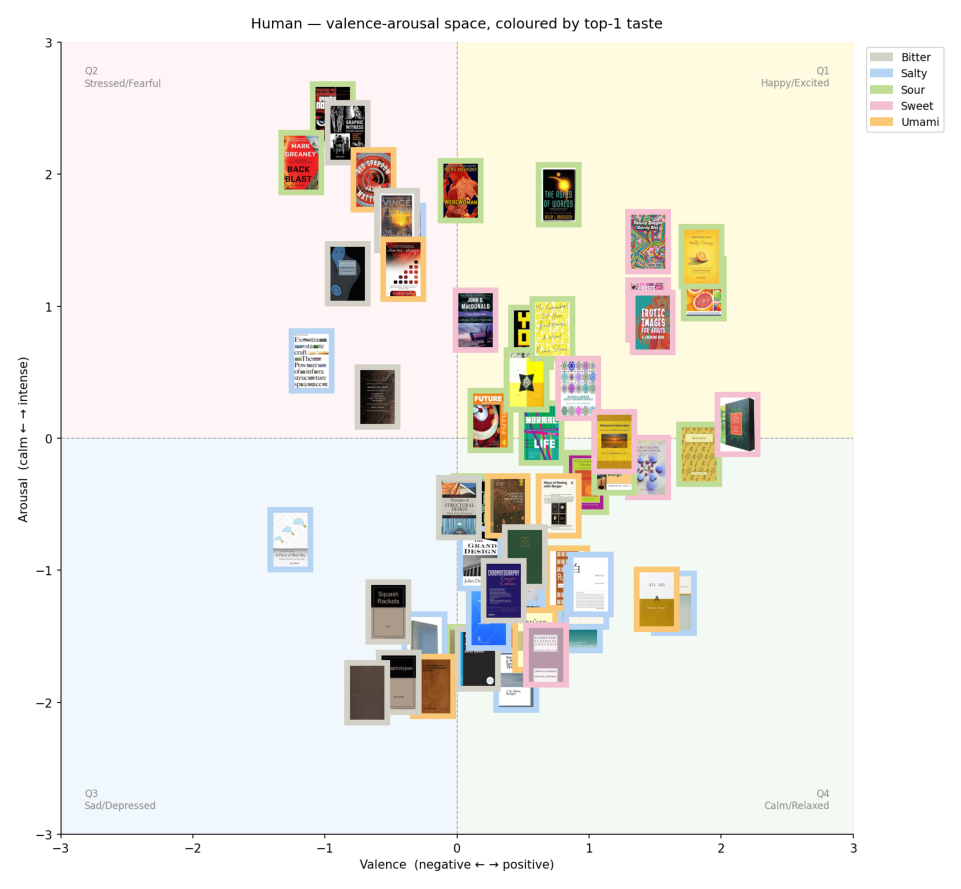

In [29]:
# VA plot 2: Human, coloured by taste
# Image paths must follow all_filenames order (same as human_emotion_probs / human_va)
human_va_image_paths = [resolve_path(f) for f in all_filenames]

plot_va_covers(
    human_va, human_top1_taste,
    TASTE_PALETTE,
    'Human — valence-arousal space, coloured by top-1 taste',
    human_va_image_paths,
    savefile='va_human_taste.png',
    force_lim=3
)

Saved: va_clip_emotions.png


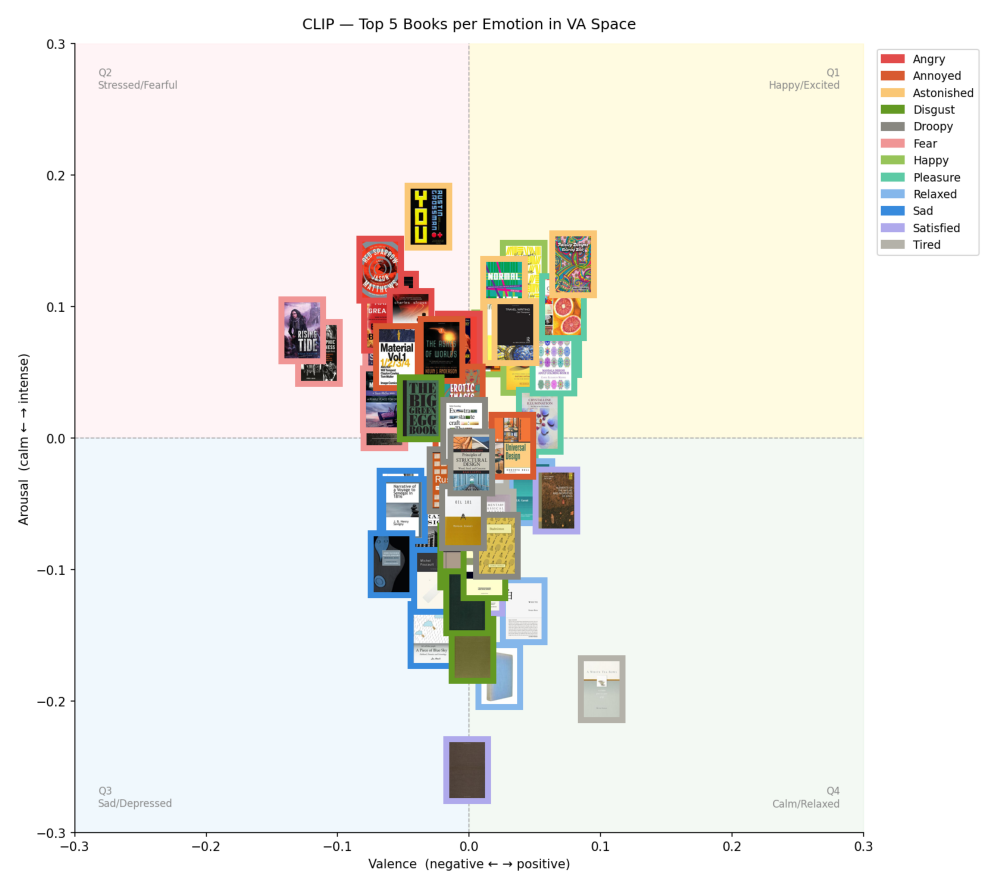

In [30]:
plot_va_covers(
    clip_va, [e.capitalize() for e in pool_emotions],
    EMOTION_PALETTE,
    'CLIP — Top 5 Books per Emotion in VA Space',
    pool_image_paths,
    savefile='va_clip_emotions.png',
    force_lim=0.3
)

Saved: va_human_emotion.png


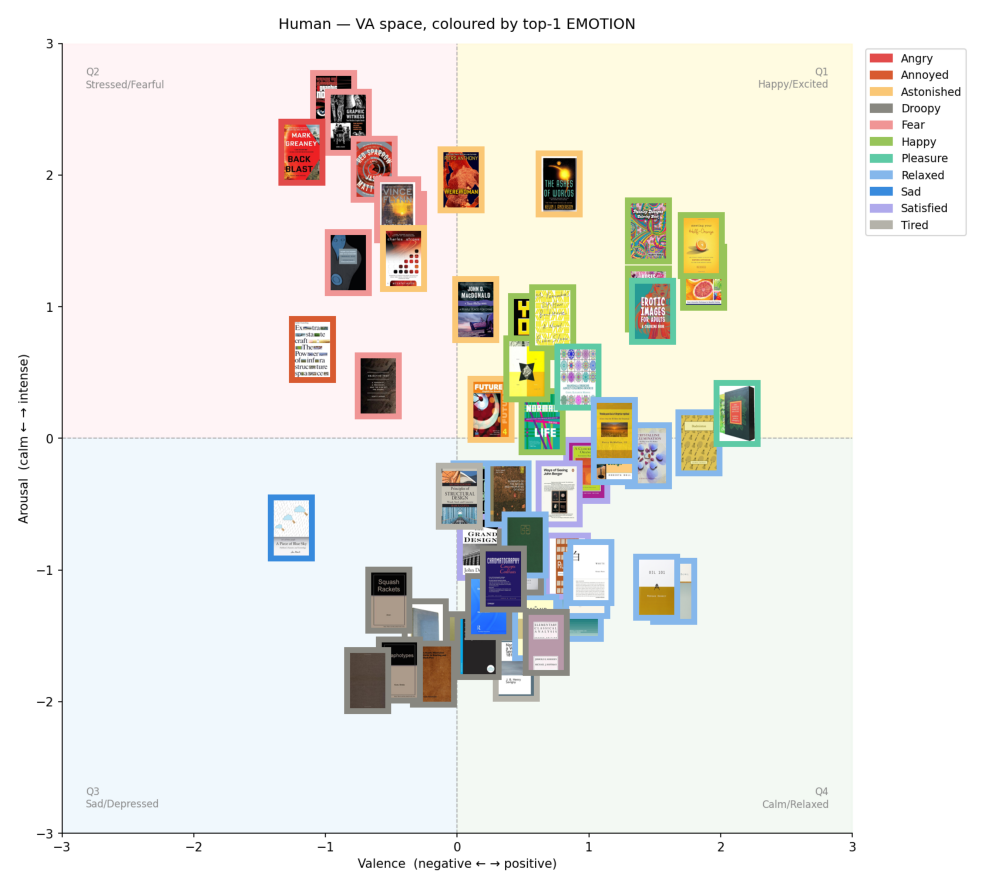

In [31]:
# Verification Plot: Coloured by the same labels used for coordinates
plot_va_covers(
    human_va, human_top1_emotion,
    EMOTION_PALETTE,
    'Human — VA space, coloured by top-1 EMOTION',
    human_va_image_paths,
    savefile='va_human_emotion.png',
    force_lim=3
)

# Section 5 — Agreement analysis
Probability-based agreement, binomial test, Jensen-Shannon Divergence

In [32]:
# from here the sheet has been updated with the original clip model book cover file name as well lol (trying to connect them by emotion is such a hassle so i just created one more column for it)

In [33]:
clip_top1_emotion_aligned = clip_em_aligned.argmax(axis=1)
clip_top1_taste_aligned   = clip_ta_aligned.argmax(axis=1)

# If Mean > Baseline: CLIP is "directionally correct" (it has some intelligence).
# If Mean ≈ Baseline: CLIP is "guessing" (it has no understanding of this category).
# If Mean < Baseline: CLIP is "counter-intuitive" (it is actively picking things humans disagree with).
emotion_agreement = human_em_aligned[np.arange(N_common), clip_top1_emotion_aligned]
taste_agreement = human_ta_aligned[np.arange(N_common), clip_top1_taste_aligned]

print(f'Agreement computed over {N_common} matched books')
print(f"\nEMOTION AGREEMENT:")
print(f"  Average Human Agreement : {np.mean(emotion_agreement):.2%}")
print(f"  Median Human Agreement  : {np.median(emotion_agreement):.2%}")
print(f"  Random Guess Baseline   : {1/len(EMOTIONS):.2%}")

print(f"\nTASTE AGREEMENT:")
print(f"  Average Human Agreement : {np.mean(taste_agreement):.2%}")
print(f"  Median Human Agreement  : {np.median(taste_agreement):.2%}")
print(f"  Random Guess Baseline   : {1/len(TASTES):.2%}")

Agreement computed over 60 matched books

EMOTION AGREEMENT:
  Average Human Agreement : 17.31%
  Median Human Agreement  : 14.52%
  Random Guess Baseline   : 8.33%

TASTE AGREEMENT:
  Average Human Agreement : 28.18%
  Median Human Agreement  : 26.79%
  Random Guess Baseline   : 20.00%


In [34]:
# Jensen-Shannon Divergence
# JSD measures how different two probability distributions are.
# Range: 0 (identical) to 1 (completely different).
# We compare three pairs:
#   1. CLIP vs Human        — the actual agreement we care about
#   2. Human vs Uniform     — baseline: how different humans are from random
# If CLIP vs Human ≈ Human vs Uniform, CLIP is no better than random.
# If CLIP vs Human << Human vs Uniform, CLIP meaningfully agrees with humans.

# “Does CLIP think like humans or just guess correctly sometimes?”

uniform_emotion = np.full(len(EMOTIONS), 1.0 / len(EMOTIONS))
uniform_taste   = np.full(len(TASTES),   1.0 / len(TASTES))

js_emotion, js_taste = [], []
js_baseline_em, js_baseline_ta = [], []

for i in range(N_common):
    js_emotion.append(jensenshannon(human_em_aligned[i], clip_em_aligned[i]))
    js_taste.append(jensenshannon(human_ta_aligned[i],   clip_ta_aligned[i]))

    js_baseline_em.append(jensenshannon(human_em_aligned[i], uniform_emotion))
    js_baseline_ta.append(jensenshannon(human_ta_aligned[i], uniform_taste))

jsd_em, jsd_ta   = np.mean(js_emotion), np.mean(js_taste)
base_em, base_ta = np.mean(js_baseline_em), np.mean(js_baseline_ta)

improvement_em = base_em - jsd_em
improvement_ta = base_ta - jsd_ta

# UPDATED THRESHOLDS: Filtering out statistical noise
THRESHOLD_STRONG = 0.05
THRESHOLD_WEAK   = 0.02

# Improvement over baseline: how much better is CLIP than random?
# Positive = CLIP is closer to humans than random is.
# Near zero or negative = CLIP is no better than random.
improvement_em = base_em - jsd_em
improvement_ta = base_ta - jsd_ta

print(f'\nEmotion:')
print(f'  CLIP vs Human JSD      : {jsd_em:.4f}')
print(f'  Random vs Human JSD    : {base_em:.4f}  (baseline)')
print(f'  Improvement over random: {improvement_em:+.4f}')
if improvement_em > THRESHOLD_STRONG:
    print("Emotion: CLIP and Humans AGREE")
elif improvement_em > THRESHOLD_WEAK:
    print("Emotion: CLIP and Humans SLIGHTLY AGREE")
else:
    print("Emotion: NO AGREEMENT (CLIP is guessing)")

print(f'\nTaste:')
print(f'  CLIP vs Human JSD      : {jsd_ta:.4f}')
print(f'  Random vs Human JSD    : {base_ta:.4f}  (baseline)')
print(f'  Improvement over random: {improvement_ta:+.4f}')
if improvement_ta > THRESHOLD_STRONG:
    print("Taste:   CLIP and Humans AGREE")
elif improvement_ta > THRESHOLD_WEAK:
    print("Taste:   CLIP and Humans SLIGHTLY AGREE")
else:
    print("Taste:   NO AGREEMENT (CLIP is guessing)")


Emotion:
  CLIP vs Human JSD      : 0.3581
  Random vs Human JSD    : 0.3674  (baseline)
  Improvement over random: +0.0094
Emotion: NO AGREEMENT (CLIP is guessing)

Taste:
  CLIP vs Human JSD      : 0.2365
  Random vs Human JSD    : 0.2461  (baseline)
  Improvement over random: +0.0097
Taste:   NO AGREEMENT (CLIP is guessing)


In [35]:
from scipy.stats import chi2_contingency
import warnings

# “Does CLIP respond strongly where humans are strongly opinionated?”

def get_standardised_residuals(human_counts_matrix):
    # Run Chi-square
    chi2, p, dof, expected = chi2_contingency(human_counts_matrix)

    # Calculate Standardised Residuals: (Observed - Expected) / sqrt(Expected)
    # This identifies the "hotspots" where humans felt strongest.
    residuals = (human_counts_matrix - expected) / np.sqrt(expected)
    return residuals

human_em_residuals = get_standardised_residuals(human_em_aligned)
human_ta_residuals = get_standardised_residuals(human_ta_aligned)

def check_logic_correlation(human_residuals, clip_confidence, name):
    h_flat = human_residuals.flatten()
    c_flat = clip_confidence.flatten()

    corr, p_val = spearmanr(h_flat, c_flat)

    print(f"{name} Rationality Test")
    print(f"Correlation (ρ): {corr:.4f}")
    print(f"P-value:         {p_val:.4e}")

    if p_val < 0.05 and corr > 0.5:
        print(f"Verdict: AI and Humans share a STRONGLY SIMILAR visual logic.")
    elif p_val < 0.05 and corr > 0.3:
        print(f"Verdict: AI and Humans share a SLIGHTLY SIMILAR visual logic.")
    else:
        print(f"Verdict: AI and Humans have DIFFERENT visual logic.")
    print("\n")

# Run the tests
# Use the raw CLIP probability/similarity scores as "confidence"
check_logic_correlation(human_em_residuals, clip_em_aligned, "Emotion")
check_logic_correlation(human_ta_residuals, clip_ta_aligned, "Taste")

Emotion Rationality Test
Correlation (ρ): 0.4134
P-value:         4.3445e-31
Verdict: AI and Humans share a SLIGHTLY SIMILAR visual logic.


Taste Rationality Test
Correlation (ρ): 0.3376
P-value:         1.9695e-09
Verdict: AI and Humans share a SLIGHTLY SIMILAR visual logic.




In [36]:
# Check how flat/peaked the CLIP probability distributions are
print("CLIP emotion probs — mean entropy per book:")
clip_em_entropy = -np.sum(clip_emotion_probs * np.log(clip_emotion_probs + 1e-10), axis=1)
uniform_entropy  = -np.log(1/len(EMOTIONS))
print(f"  Mean entropy:    {clip_em_entropy.mean():.4f}")
print(f"  Uniform entropy: {uniform_entropy:.4f}  (max possible)")

print("\nCLIP taste probs — mean entropy per book:")
clip_ta_entropy = -np.sum(clip_taste_probs * np.log(clip_taste_probs + 1e-10), axis=1)
uniform_entropy_ta = -np.log(1/len(TASTES))
print(f"  Mean entropy:    {clip_ta_entropy.mean():.4f}")
print(f"  Uniform entropy: {uniform_entropy_ta:.4f}  (max possible)")

print("\nHuman emotion probs — mean entropy per book:")
human_em_entropy = -np.sum(human_emotion_probs * np.log(human_emotion_probs + 1e-10), axis=1)
print(f"  Mean entropy:    {human_em_entropy.mean():.4f}")

print("\nHuman taste probs — mean entropy per book:")
human_ta_entropy = -np.sum(human_taste_probs * np.log(human_taste_probs + 1e-10), axis=1)
print(f"  Mean entropy:    {human_ta_entropy.mean():.4f}")


CLIP emotion probs — mean entropy per book:
  Mean entropy:    2.4818
  Uniform entropy: 2.4849  (max possible)

CLIP taste probs — mean entropy per book:
  Mean entropy:    1.6060
  Uniform entropy: 1.6094  (max possible)

Human emotion probs — mean entropy per book:
  Mean entropy:    1.9361

Human taste probs — mean entropy per book:
  Mean entropy:    1.3440


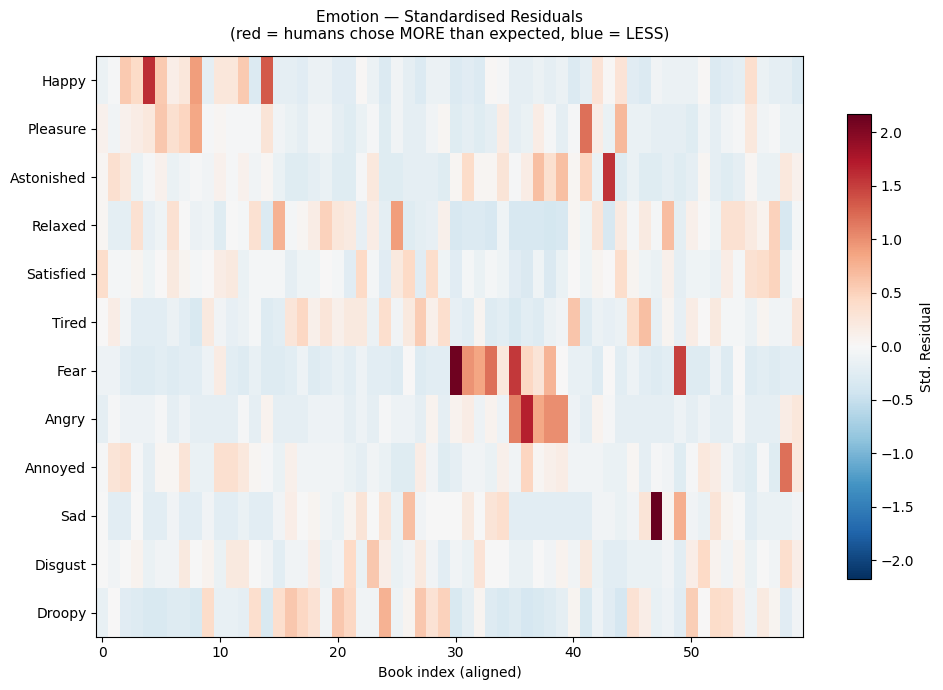

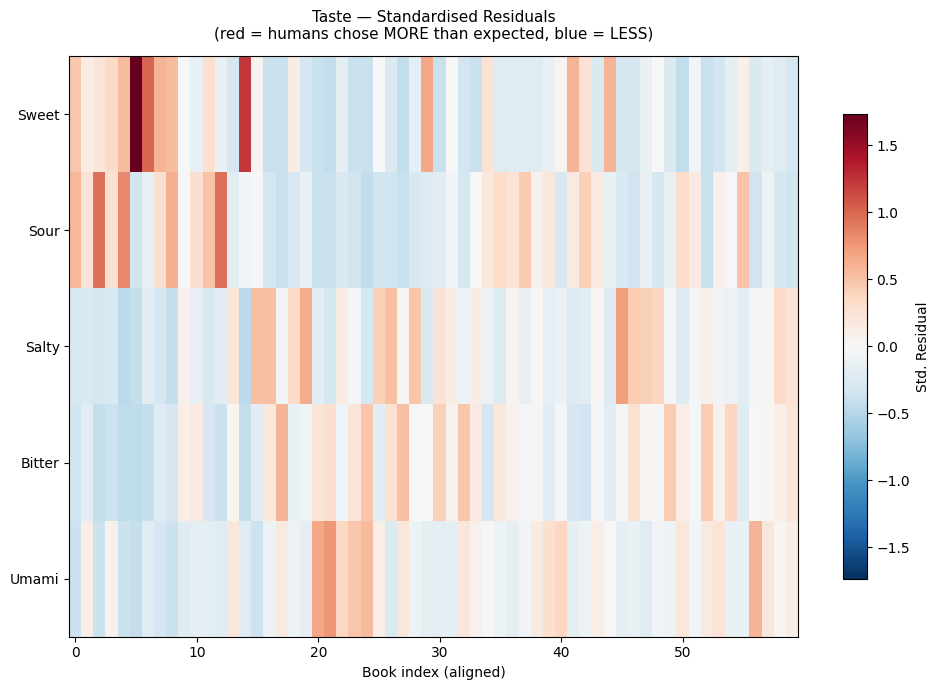

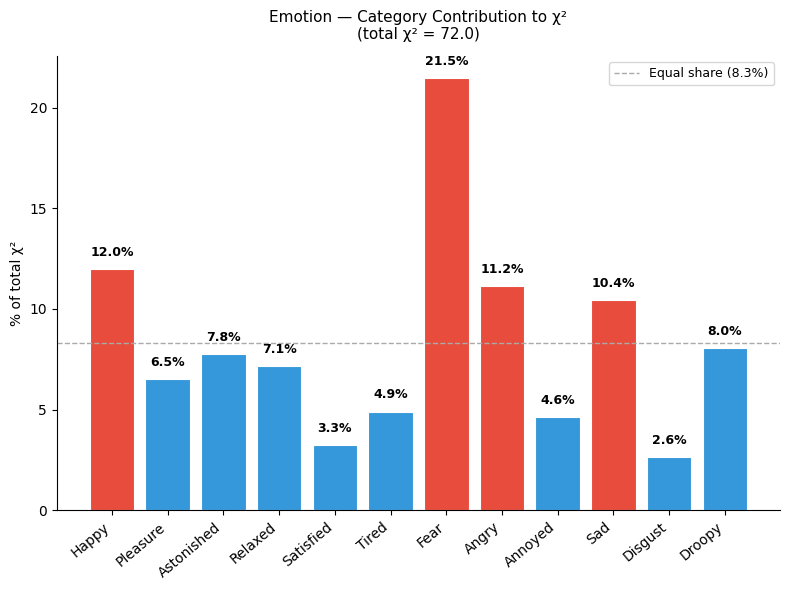

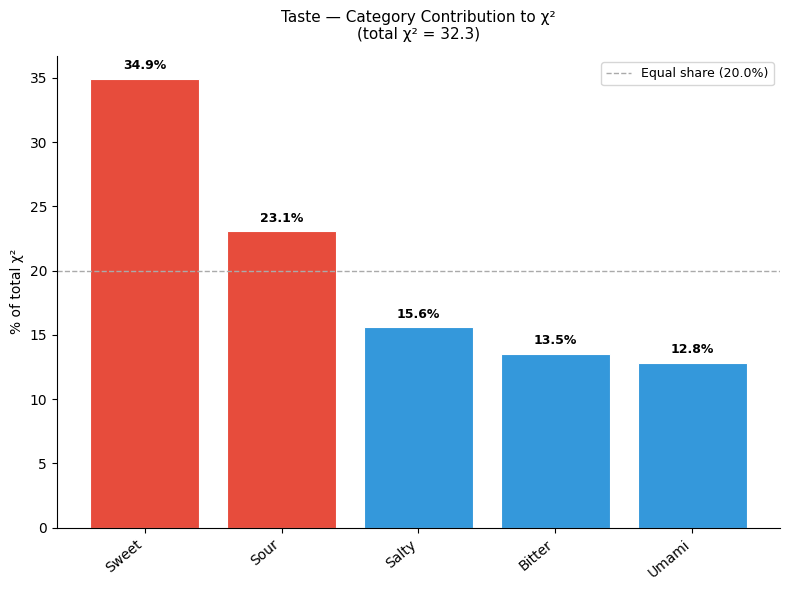

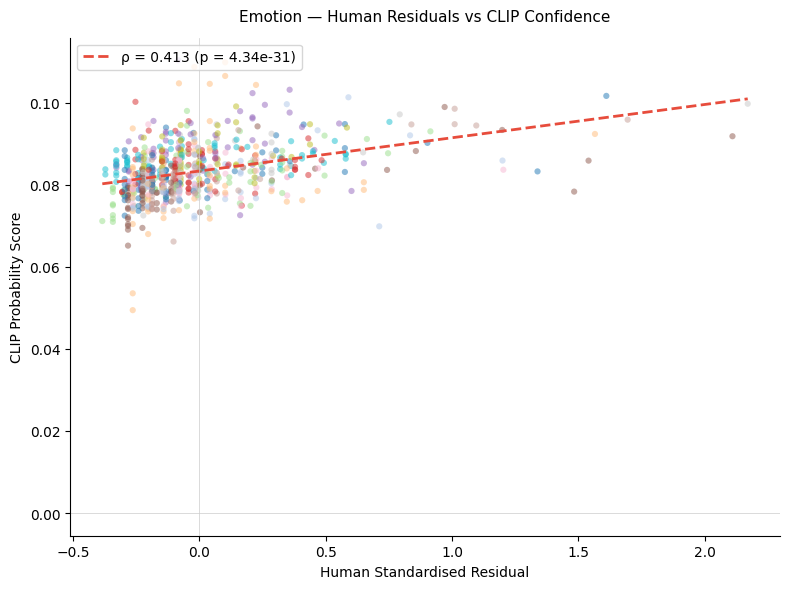

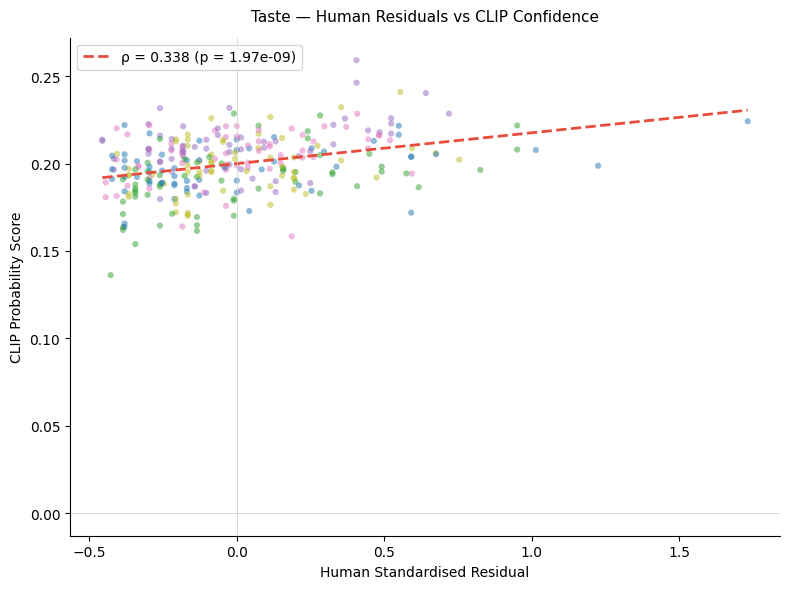

In [37]:
# List of data to iterate through for individual plots
data_configs = [
    ('Emotion', human_em_residuals, EMOTIONS, clip_em_aligned),
    ('Taste',   human_ta_residuals, TASTES,   clip_ta_aligned)
]

# 1. Residual heatmaps
for title, residuals, labels, _ in data_configs:
    plt.figure(figsize=(10, 7))
    # Rows = books, Cols = labels → transpose so labels are on y-axis
    im = plt.imshow(residuals.T, cmap='RdBu_r', aspect='auto',
                    vmin=-np.abs(residuals).max(), vmax=np.abs(residuals).max())

    plt.yticks(range(len(labels)), labels, fontsize=10)
    plt.xlabel('Book index (aligned)', fontsize=10)
    plt.title(f'{title} — Standardised Residuals\n'
              f'(red = humans chose MORE than expected, blue = LESS)',
              fontsize=11, pad=12)

    plt.colorbar(im, shrink=0.8, label='Std. Residual')
    plt.tight_layout()
    plt.savefig(f'residual_heatmap_{title.lower()}.png', dpi=150, bbox_inches='tight')
    plt.show()


# 2. Aggregated residual bar charts (Individual)
for title, residuals, labels, _ in data_configs:
    plt.figure(figsize=(8, 6))

    contrib = np.sum(residuals ** 2, axis=0)
    total_chi2 = np.sum(contrib)
    pct = contrib / total_chi2 * 100

    colors = ['#e74c3c' if p > 100/len(labels) else '#3498db' for p in pct]
    bars = plt.bar(range(len(labels)), pct, color=colors, edgecolor='white', linewidth=0.8)

    for bar, p in zip(bars, pct):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{p:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

    plt.axhline(100/len(labels), color='#aaa', linestyle='--', linewidth=1,
                label=f'Equal share ({100/len(labels):.1f}%)')
    plt.xticks(range(len(labels)), labels, rotation=40, ha='right', fontsize=10)
    plt.ylabel('% of total χ²', fontsize=10)
    plt.title(f'{title} — Category Contribution to χ²\n'
              f'(total χ² = {total_chi2:.1f})', fontsize=11, pad=12)

    plt.gca().spines[['top', 'right']].set_visible(False)
    plt.legend(fontsize=9)
    plt.tight_layout()
    plt.savefig(f'chi2_contribution_{title.lower()}.png', dpi=150, bbox_inches='tight')
    plt.show()


# 3. Residual vs CLIP confidence scatter
for title, h_res, labels, c_conf in data_configs:
    plt.figure(figsize=(8, 6))

    h_flat = h_res.flatten()
    c_flat = c_conf.flatten()
    corr, p_val = spearmanr(h_flat, c_flat)

    n_books, n_cats = h_res.shape
    cat_indices = np.tile(np.arange(n_cats), n_books)
    palette = plt.cm.tab10 if n_cats <= 10 else plt.cm.tab20
    colors = [palette(ci / n_cats) for ci in cat_indices]

    plt.scatter(h_flat, c_flat, c=colors, alpha=0.5, s=20, edgecolors='none')

    # Trend line
    z = np.polyfit(h_flat, c_flat, 1)
    x_line = np.linspace(h_flat.min(), h_flat.max(), 100)
    plt.plot(x_line, np.polyval(z, x_line), color='#e74c3c', linewidth=2,
             linestyle='--', label=f'ρ = {corr:.3f} (p = {p_val:.2e})')

    plt.axhline(0, color='#ccc', linewidth=0.5)
    plt.axvline(0, color='#ccc', linewidth=0.5)
    plt.xlabel('Human Standardised Residual', fontsize=10)
    plt.ylabel('CLIP Probability Score', fontsize=10)
    plt.title(f'{title} — Human Residuals vs CLIP Confidence', fontsize=11, pad=12)
    plt.gca().spines[['top', 'right']].set_visible(False)
    plt.legend(fontsize=10, loc='upper left')

    plt.tight_layout()
    plt.savefig(f'residual_vs_clip_{title.lower()}.png', dpi=150, bbox_inches='tight')
    plt.show()

In [38]:
# Cohen Kappa
from sklearn.metrics import cohen_kappa_score, confusion_matrix

# Cohen's Kappa measures agreement between two raters beyond what would be expected by chance alone
# Two "raters":
#   - CLIP:  top-1 category (argmax of CLIP probability vector)
#   - Human: top-1 category (argmax of human probability vector, i.e. plurality vote)
# Items: the N_common aligned books

clip_top1_em  = clip_em_aligned.argmax(axis=1)   # CLIP's top-1 emotion per book
human_top1_em = human_em_aligned.argmax(axis=1)   # Human's top-1 emotion per book

clip_top1_ta  = clip_ta_aligned.argmax(axis=1)    # CLIP's top-1 taste per book
human_top1_ta = human_ta_aligned.argmax(axis=1)   # Human's top-1 taste per book

kappa_emotion = cohen_kappa_score(human_top1_em, clip_top1_em)
kappa_taste   = cohen_kappa_score(human_top1_ta, clip_top1_ta)

def interpret_kappa(k):
    if k < 0.00: return 'Poor (worse than chance)'
    if k <= 0.20: return 'Slight'
    if k <= 0.40: return 'Fair'
    if k <= 0.60: return 'Moderate'
    if k <= 0.80: return 'Substantial'
    return 'Almost perfect'

print(f'Cohen\'s Kappa — CLIP vs Human Agreement')
print(f'  Emotion κ = {kappa_emotion:.4f}  →  {interpret_kappa(kappa_emotion)}')
print(f'  Taste   κ = {kappa_taste:.4f}  →  {interpret_kappa(kappa_taste)}')
print(f'  N books   = {N_common}')

Cohen's Kappa — CLIP vs Human Agreement
  Emotion κ = 0.0625  →  Slight
  Taste   κ = 0.1649  →  Slight
  N books   = 60


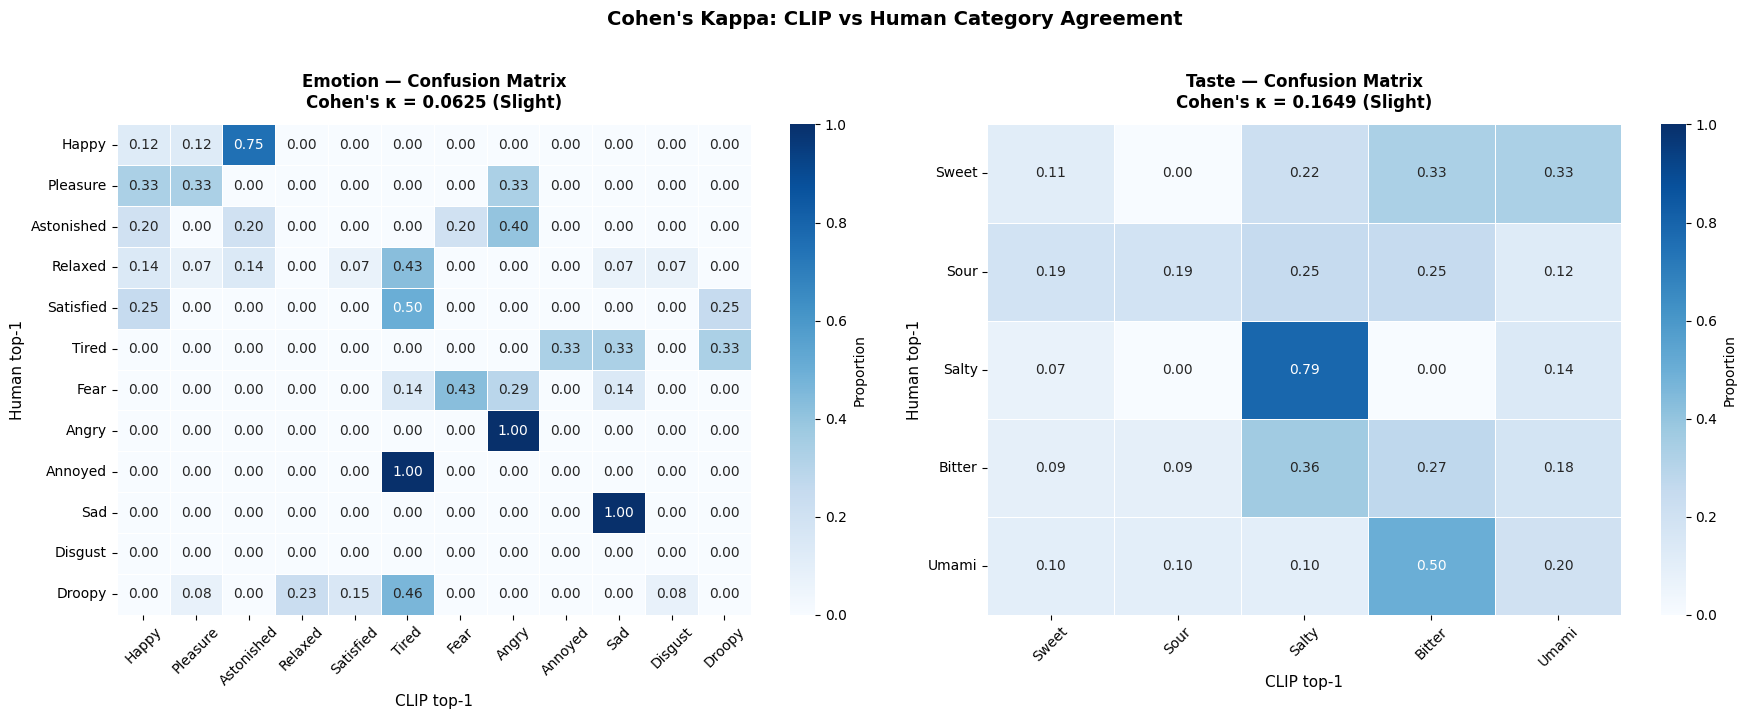



Per-category agreement (diagonal of confusion matrix):

Emotion:
  Happy            1/8  books agreed  ( 12.5%)
  Pleasure         1/3  books agreed  ( 33.3%)
  Astonished       1/5  books agreed  ( 20.0%)
  Relaxed          0/14 books agreed  (  0.0%)
  Satisfied        0/4  books agreed  (  0.0%)
  Tired            0/3  books agreed  (  0.0%)
  Fear             3/7  books agreed  ( 42.9%)
  Angry            1/1  books agreed  (100.0%)
  Annoyed          0/1  books agreed  (  0.0%)
  Sad              1/1  books agreed  (100.0%)
  Disgust         no books assigned by humans
  Droopy           0/13 books agreed  (  0.0%)

Taste:
  Sweet            1/9  books agreed  ( 11.1%)
  Sour             3/16 books agreed  ( 18.8%)
  Salty           11/14 books agreed  ( 78.6%)
  Bitter           3/11 books agreed  ( 27.3%)
  Umami            2/10 books agreed  ( 20.0%)


In [39]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, (human_labels, clip_labels, label_names, domain, kappa) in zip(axes, [
    (human_top1_em, clip_top1_em, EMOTIONS, 'Emotion', kappa_emotion),
    (human_top1_ta, clip_top1_ta, TASTES,   'Taste',   kappa_taste),
]):
    cm = confusion_matrix(human_labels, clip_labels, labels=range(len(label_names)))

    # Normalise by row (human) so each row sums to 1 — shows
    # "given humans said X, what did CLIP say?"
    row_sums = cm.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1  # avoid division by zero
    cm_norm = cm / row_sums

    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=label_names, yticklabels=label_names,
                ax=ax, vmin=0, vmax=1, linewidths=0.5, linecolor='white',
                cbar_kws={'label': 'Proportion'})

    ax.set_xlabel('CLIP top-1', fontsize=11)
    ax.set_ylabel('Human top-1', fontsize=11)
    ax.set_title(f'{domain} — Confusion Matrix\n'
                 f'Cohen\'s κ = {kappa:.4f} ({interpret_kappa(kappa)})',
                 fontsize=12, fontweight='bold', pad=12)
    ax.tick_params(axis='x', rotation=45)
    ax.tick_params(axis='y', rotation=0)

fig.suptitle('Cohen\'s Kappa: CLIP vs Human Category Agreement',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('cohens_kappa_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n\nPer-category agreement (diagonal of confusion matrix):')

for domain, human_labels, clip_labels, label_names in [
    ('Emotion', human_top1_em, clip_top1_em, EMOTIONS),
    ('Taste',   human_top1_ta, clip_top1_ta, TASTES),
]:
    cm = confusion_matrix(human_labels, clip_labels, labels=range(len(label_names)))
    row_sums = cm.sum(axis=1)

    print(f'\n{domain}:')
    for i, name in enumerate(label_names):
        if row_sums[i] > 0:
            agree_pct = cm[i, i] / row_sums[i] * 100
            print(f'  {name:<14s}  {cm[i,i]:>2d}/{row_sums[i]:<2d} books agreed  '
                  f'({agree_pct:5.1f}%)')
        else:
            print(f'  {name:<14s}  no books assigned by humans')

